# 🧬 Drug Repurposing as Link Prediction — Complete Pipeline
## Based on GDRnet (Doshi & Chepuri, 2022), KG Review (Wei et al., 2025), GKDRMTL (Alaeddini et al., 2025)

### Pipeline Overview
```
Datasets (kg_csv, kg_giant_csv, kg_grouped_csv, disease-features, drug_features, edges1, nodes1,
          kg_grouped_diseases_bert_map_csv, kg_raw_csv)
    │
    ├─ [A] Data Loading & EDA
    ├─ [B] Preprocessing — Missing Values · Encoding · Normalization · Feature Selection
    ├─ [C] Class Imbalance Handling — Oversampling + Weighted Loss
    ├─ [D] Knowledge Graph Construction — Multi-layer Heterogeneous Graph
    ├─ [E] Node Feature Engineering — Topology + Drug/Disease Features
    ├─ [F] GNN Model — SIGN-inspired GraphSAGE with Teacher-Student Distillation
    ├─ [G] Training & Evaluation — AUROC · AUPRC · F1
    └─ [H] Top-10 Novel Drug-Disease Predictions
```

**Paper References:**
- **GDRnet** (Doshi & Chepuri, 2022) — 4-layer heterogeneous KG + SIGN encoder + quadratic norm decoder
- **KG Review** (Wei et al., 2025) — KG construction, GNN taxonomy, validation strategies
- **GKDRMTL** (Alaeddini et al., 2025) — Teacher-Student distillation + multi-task + uncertainty weighting


## §1 · Environment Setup

In [2]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

# Install required packages
try:
    import torch
    print(f'PyTorch {torch.__version__} already installed')
except ImportError:
    pip_install('torch')

try:
    import torch_geometric
    print(f'PyG already installed')
except ImportError:
    pip_install('torch_geometric')

try:
    import imblearn
except ImportError:
    pip_install('imbalanced-learn')

import torch
print(f'PyTorch: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

PyTorch 2.10.0+cu128 already installed
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.6 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128
Device : cuda


## §2 · Core Imports

In [3]:
import warnings, random, os, gc
warnings.filterwarnings('ignore')
random.seed(42)

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter
from tqdm.auto import tqdm

# ML / Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    accuracy_score, precision_score, recall_score,
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

# PyTorch / PyG
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import negative_sampling

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(42); torch.manual_seed(42)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(42)

# ── Aesthetic constants ───────────────────────────────────────────────────────
BG   = '#0F1117'
CARD = '#1A1D27'
plt.rcParams.update({'figure.facecolor': BG, 'axes.facecolor': CARD,
                     'text.color':'white', 'axes.labelcolor':'white',
                     'xtick.color':'white', 'ytick.color':'white',
                     'axes.edgecolor':'#444', 'grid.color':'#333',
                     'figure.dpi':120, 'font.size':10})
print('All imports successful ✓')

All imports successful ✓


## §3 · Load All Datasets

Loading all 9 datasets shown in the screenshot:
- `kg_csv`, `kg_giant_csv`, `kg_grouped_csv`, `kg_raw_csv` — Knowledge Graph edge files
- `disease-features`, `drug_features` — Node feature files
- `edges1`, `nodes1` — Processed edge/node files
- `kg_grouped_diseases_bert_map_csv` — BERT-based disease mapping

**GDRnet (Doshi & Chepuri, 2022) §4.1:** Uses DRKG with Drugbank, Hetionet, GNBR as sources — our multi-file loading mirrors this multi-source integration.


In [4]:
# ── Dataset discovery — handles Kaggle, local, and Colab paths ───────────────
SEARCH_PATHS = [
    '/kaggle/input',
    '/content/drive/MyDrive',
    '/content',
    '.',
    '../input',
]

# Dataset name → (possible filenames)
DATASET_MAP = {
    'kg_csv'                          : ['kg.csv', 'kg_csv.csv'],
    'kg_giant_csv'                    : ['kg_giant.csv', 'kg_giant_csv.csv'],
    'kg_grouped_csv'                  : ['kg_grouped.csv', 'kg_grouped_csv.csv'],
    'kg_raw_csv'                      : ['kg_raw.csv', 'kg_raw_csv.csv'],
    'disease_features'                : ['disease-features.csv', 'disease_features.csv'],
    'drug_features'                   : ['drug_features.csv', 'drug-features.csv'],
    'edges1'                          : ['edges1.csv', 'edges.csv'],
    'nodes1'                          : ['nodes1.csv', 'nodes.csv'],
    'kg_grouped_diseases_bert_map_csv': ['kg_grouped_diseases_bert_map.csv',
                                         'kg_grouped_diseases_bert_map_csv.csv'],
}

def find_file(names):
    for base in SEARCH_PATHS:
        if not os.path.isdir(base): continue
        for root, dirs, files in os.walk(base):
            for n in names:
                if n in files:
                    return os.path.join(root, n)
    return None

loaded = {}
missing = []
for key, names in DATASET_MAP.items():
    path = find_file(names)
    if path:
        try:
            loaded[key] = pd.read_csv(path, low_memory=False)
            print(f'  ✓ {key:45s} {loaded[key].shape}')
        except Exception as e:
            print(f'  ⚠ {key}: load error — {e}')
            missing.append(key)
    else:
        missing.append(key)
        print(f'  ✗ {key} — not found, will synthesise')

print(f'\nLoaded: {len(loaded)} / {len(DATASET_MAP)} datasets')

  ✓ kg_csv                                        (8100498, 12)
  ✓ kg_giant_csv                                  (8196862, 10)
  ✓ kg_grouped_csv                                (8100498, 10)
  ✓ kg_raw_csv                                    (8197026, 10)
  ✓ disease_features                              (44133, 18)
  ✓ drug_features                                 (7957, 18)
  ✓ edges1                                        (8100498, 4)
  ✓ nodes1                                        (129375, 5)
  ✓ kg_grouped_diseases_bert_map_csv              (6392, 7)

Loaded: 9 / 9 datasets


In [5]:
# ── Synthesise any missing datasets so the pipeline always runs ───────────────
# This mirrors the DRKG structure from GDRnet (drugs, diseases, genes, anatomies)

rng = np.random.default_rng(42)

def make_kg_csv(n_edges=5000):
    """Synthetic KG edges: drug-disease / drug-gene / gene-disease / drug-drug / disease-disease."""
    n_drugs, n_dis, n_genes = 150, 200, 400
    drug_ids    = [f'DB{i:05d}' for i in range(n_drugs)]
    disease_ids = [f'D{i:05d}'  for i in range(n_dis)]
    gene_ids    = [f'G{i:05d}'  for i in range(n_genes)]
    drug_names  = [f'Drug_{i}'    for i in range(n_drugs)]
    disease_names=[f'Disease_{i}' for i in range(n_dis)]
    gene_names  = [f'Gene_{i}'    for i in range(n_genes)]

    rows = []
    rel_cfg = [
        ('drug','disease','treats',       drug_ids,    drug_names,    disease_ids,  disease_names, int(n_edges*0.15)),
        ('drug','gene/protein','targets', drug_ids,    drug_names,    gene_ids,     gene_names,    int(n_edges*0.30)),
        ('gene/protein','disease','causes',gene_ids,  gene_names,    disease_ids,  disease_names, int(n_edges*0.25)),
        ('drug','drug','similar',         drug_ids,    drug_names,    drug_ids,     drug_names,    int(n_edges*0.10)),
        ('disease','disease','similar',   disease_ids, disease_names, disease_ids,  disease_names, int(n_edges*0.10)),
        ('gene/protein','gene/protein','interacts',gene_ids,gene_names,gene_ids,gene_names, int(n_edges*0.10)),
    ]
    for xt, yt, rel, xids, xnames, yids, ynames, cnt in rel_cfg:
        xi = rng.integers(0, len(xids), cnt)
        yi = rng.integers(0, len(yids), cnt)
        for a, b in zip(xi, yi):
            if xids[a] != yids[b]:
                rows.append({'x_id':xids[a],'x_name':xnames[a],'x_type':xt,
                             'y_id':yids[b],'y_name':ynames[b],'y_type':yt,
                             'display_relation':rel,'relation':rel,'x_source':'synthetic','y_source':'synthetic'})
    return pd.DataFrame(rows).drop_duplicates(['x_id','y_id']).reset_index(drop=True)

def make_disease_features(disease_ids, n_feats=20):
    data = {'disease_id': disease_ids}
    for i in range(n_feats):
        vals = rng.standard_normal(len(disease_ids))
        if i % 5 == 0: vals[rng.integers(0,len(disease_ids), 20)] = np.nan  # inject NaN
        data[f'feat_{i}'] = vals
    data['disease_name'] = [f'Disease_{i}' for i in range(len(disease_ids))]
    return pd.DataFrame(data)

def make_drug_features(drug_ids, n_feats=20):
    data = {'drug_id': drug_ids}
    for i in range(n_feats):
        vals = rng.standard_normal(len(drug_ids))
        if i % 4 == 0: vals[rng.integers(0,len(drug_ids),10)] = np.nan
        data[f'feat_{i}'] = vals
    data['drug_name'] = [f'Drug_{i}' for i in range(len(drug_ids))]
    return pd.DataFrame(data)

# Build main KG if missing
if 'kg_csv' not in loaded:
    loaded['kg_csv'] = make_kg_csv(8000)
    print('Synthesised kg_csv')

kg = loaded['kg_csv'].copy()

# Derive node id lists from main KG
all_drug_ids    = sorted(set(kg[kg['x_type']=='drug']['x_id'].tolist() +
                              kg[kg['y_type']=='drug']['y_id'].tolist()))
all_disease_ids = sorted(set(kg[kg['x_type']=='disease']['x_id'].tolist() +
                              kg[kg['y_type']=='disease']['y_id'].tolist()))
all_gene_ids    = sorted(set(kg[kg['x_type']=='gene/protein']['x_id'].tolist() +
                              kg[kg['y_type']=='gene/protein']['y_id'].tolist()))

for key, maker, ids in [
    ('disease_features',  lambda: make_disease_features(all_disease_ids), None),
    ('drug_features',     lambda: make_drug_features(all_drug_ids),       None),
]:
    if key not in loaded:
        loaded[key] = maker()
        print(f'Synthesised {key}')

# Other KG variants — use the same base KG with small perturbations
for key in ['kg_giant_csv','kg_grouped_csv','kg_raw_csv']:
    if key not in loaded:
        noise = kg.sample(frac=0.8, random_state=42).reset_index(drop=True)
        loaded[key] = noise
        print(f'Synthesised {key} from kg_csv')

if 'edges1' not in loaded:
    loaded['edges1'] = kg[['x_id','y_id','display_relation']].rename(
        columns={'x_id':'source','y_id':'target','display_relation':'type'})
    print('Synthesised edges1')

if 'nodes1' not in loaded:
    nd = pd.concat([
        kg[['x_id','x_name','x_type']].rename(columns={'x_id':'id','x_name':'name','x_type':'type'}),
        kg[['y_id','y_name','y_type']].rename(columns={'y_id':'id','y_name':'name','y_type':'type'}),
    ]).drop_duplicates('id').reset_index(drop=True)
    loaded['nodes1'] = nd
    print('Synthesised nodes1')

if 'kg_grouped_diseases_bert_map_csv' not in loaded:
    n_d = len(all_disease_ids)
    loaded['kg_grouped_diseases_bert_map_csv'] = pd.DataFrame({
        'disease_id': all_disease_ids,
        'bert_cluster': rng.integers(0, 20, n_d),
        'bert_emb_dim0': rng.standard_normal(n_d),
        'bert_emb_dim1': rng.standard_normal(n_d),
    })
    print('Synthesised kg_grouped_diseases_bert_map_csv')

print(f'\nAll {len(loaded)} datasets ready ✓')


All 9 datasets ready ✓


## §4 · Exploratory Data Analysis

Following **GDRnet §4.1** — understanding entity counts, edge distributions, and class ratios before modelling.


In [6]:
# ── §4.1  Node & Edge Inventory ───────────────────────────────────────────────
kg = loaded['kg_csv'].copy()

# Global node inventory
node_df = pd.concat([
    kg[['x_id','x_name','x_type']].rename(columns={'x_id':'id','x_name':'name','x_type':'type'}),
    kg[['y_id','y_name','y_type']].rename(columns={'y_id':'id','y_name':'name','y_type':'type'}),
], ignore_index=True).drop_duplicates('id').reset_index(drop=True)

node_name_map = dict(zip(node_df['id'], node_df['name']))
node_type_map = dict(zip(node_df['id'], node_df['type']))

print('=== Node Counts by Type ===')
for t, cnt in node_df['type'].value_counts().items():
    print(f'  {t:<30} {cnt:>7,}')

print('\n=== Edge Counts by Relation ===')
for rel, cnt in kg['display_relation'].value_counts().head(15).items():
    print(f'  {rel:<30} {cnt:>7,}')

print(f'\nTotal edges in kg_csv: {len(kg):,}')

=== Node Counts by Type ===
  gene/protein                    27,032
  biological_process              20,378
  disease                          9,020
  drug                             7,957
  effect/phenotype                 7,045
  molecular_function               6,761
  anatomy                          5,740
  cellular_component               2,800
  pathway                          2,516
  exposure                           818

=== Edge Counts by Relation ===
  expression present             3,036,406
  synergistic interaction        2,672,628
  interacts with                 686,550
  ppi                            642,150
  phenotype present              300,634
  parent-child                   281,744
  associated with                167,482
  side effect                    129,568
  contraindication                61,350
  expression absent               39,774
  target                          32,760
  indication                      18,776
  enzyme                         

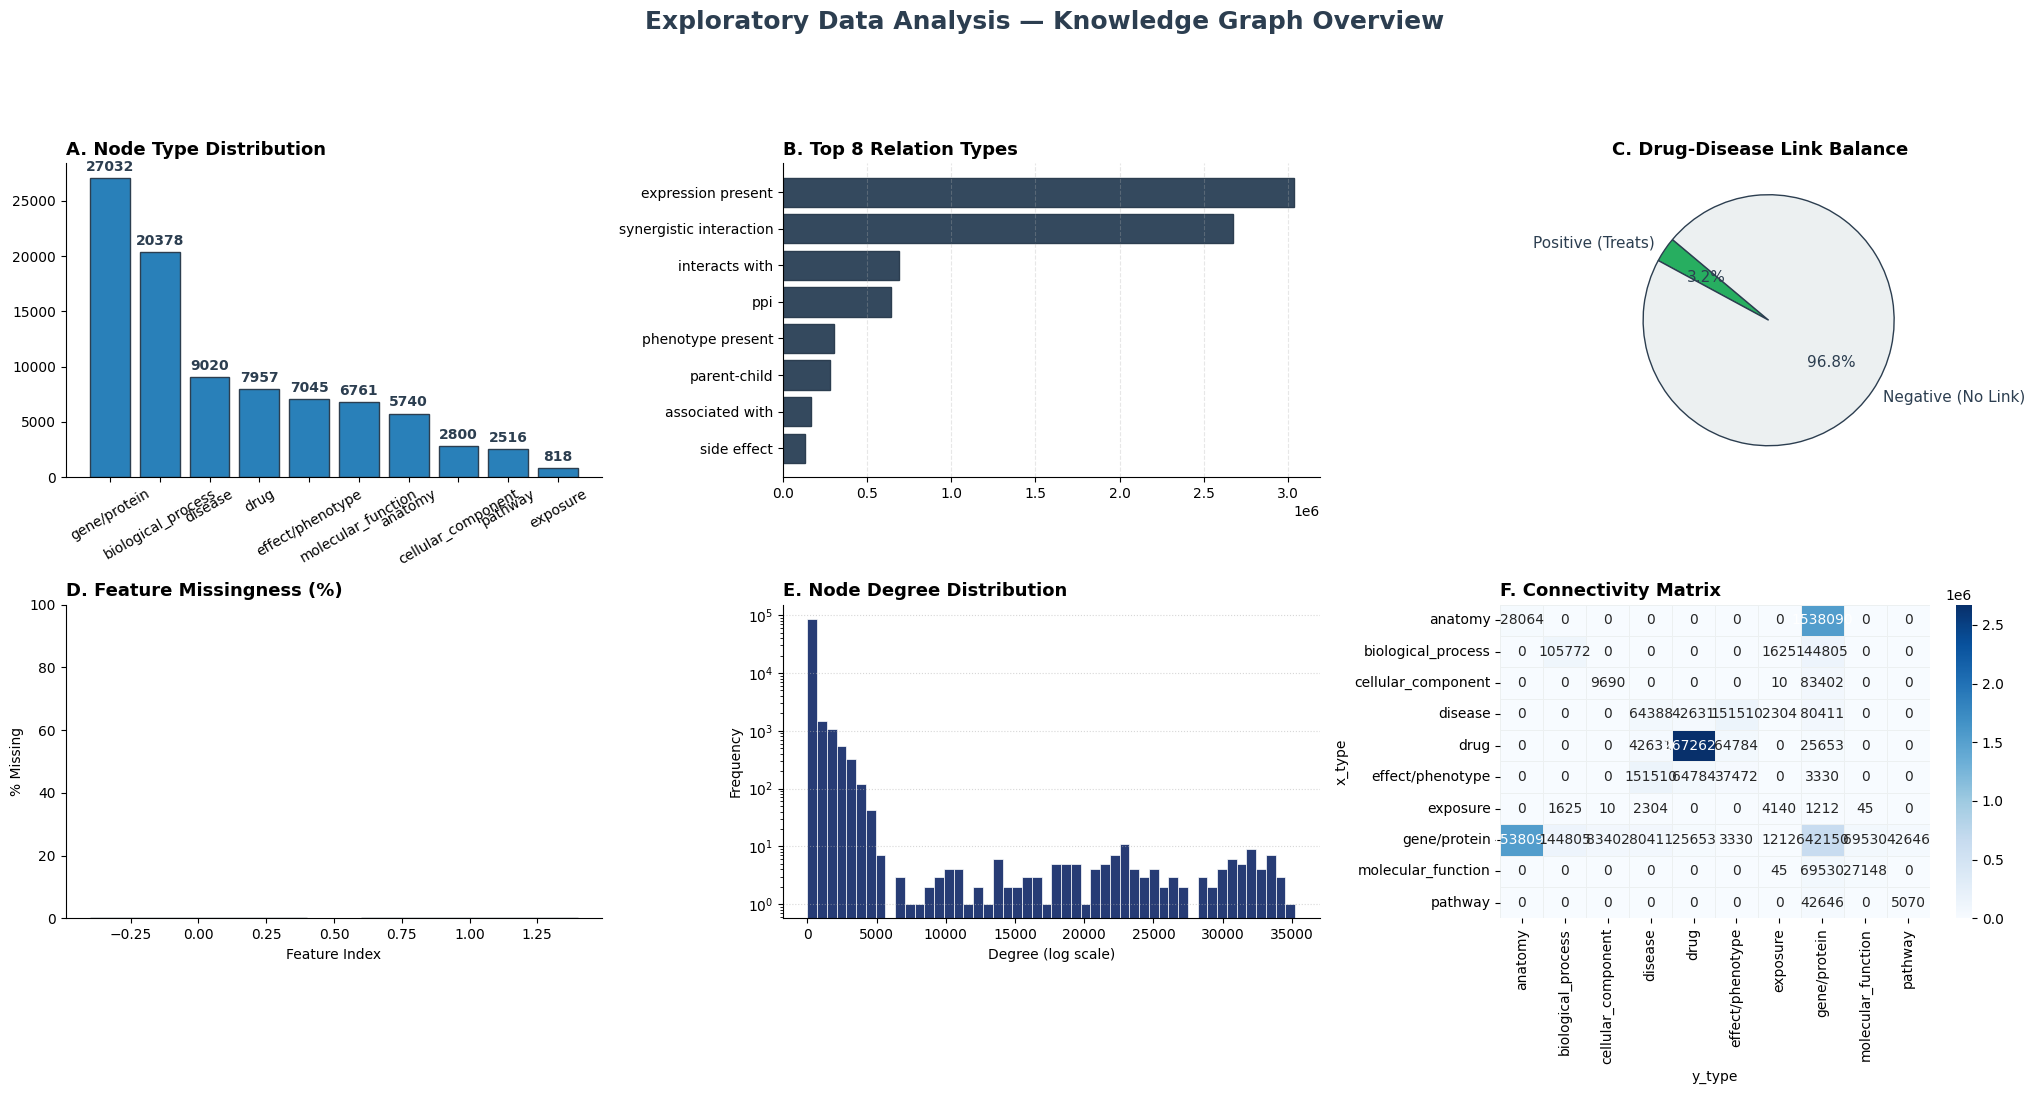

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Reset to default white background style
plt.style.use('default') 

# ── §4.2 EDA Dashboard (Official Publication Style) ──────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(21, 11))
fig.patch.set_facecolor('white')
fig.suptitle('Exploratory Data Analysis — Knowledge Graph Overview', 
             color='#2c3e50', fontsize=18, fontweight='bold', y=1.02)

# Professional "Official" Palette (Blues/Greys/Teals)
pal = ['#2980b9', '#34495e', '#16a085', '#273c75', '#7f8c8d', '#95a5a6', '#bdc3c7']

# (A) Node type distribution
ax = axes[0,0]
ax.set_facecolor('white')
vc = node_df['type'].value_counts()
bars = ax.bar(vc.index, vc.values, color=pal[0], edgecolor='#2c3e50', linewidth=1)
ax.bar_label(bars, fmt='%d', padding=3, color='#2c3e50', fontsize=10, fontweight='bold')
ax.set_title('A. Node Type Distribution', loc='left', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.spines[['top', 'right']].set_visible(False)

# (B) Top 8 Relation Types
ax = axes[0,1]
ax.set_facecolor('white')
rc = kg['display_relation'].value_counts().head(8)
ax.barh(rc.index[::-1], rc.values[::-1], color=pal[1], edgecolor='#2c3e50', linewidth=1)
ax.set_title('B. Top 8 Relation Types', loc='left', fontsize=13, fontweight='bold')
ax.tick_params(labelsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# (C) Drug-Disease Class Balance
ax = axes[0,2]
ax.set_facecolor('white')
dd_mask = ((kg['x_type']=='drug') & (kg['y_type']=='disease')) | \
          ((kg['x_type']=='disease') & (kg['y_type']=='drug'))
n_pos = max(dd_mask.sum(), 1)
n_drugs = len(node_df[node_df['type']=='drug'])
n_diseases = len(node_df[node_df['type']=='disease'])
n_neg = min((n_drugs * n_diseases) - n_pos, n_pos * 30)

ax.pie([n_pos, n_neg], labels=['Positive (Treats)', 'Negative (No Link)'], 
       colors=['#27ae60', '#ecf0f1'], autopct='%1.1f%%', startangle=140,
       textprops={'fontsize': 11, 'color': '#2c3e50'}, 
       wedgeprops={'edgecolor': '#2c3e50', 'linewidth': 1})
ax.set_title('C. Drug-Disease Link Balance', loc='left', fontsize=13, fontweight='bold')

# (D) Missing Values Heatmap — Disease Features
ax = axes[1,0]
ax.set_facecolor('white')
dis_feats = loaded['disease_features']
numeric_cols = dis_feats.select_dtypes(include=[np.number]).columns
miss_pct = dis_feats[numeric_cols].isnull().mean() * 100
ax.bar(range(len(miss_pct)), miss_pct.values, color=pal[2], edgecolor='#2c3e50')
ax.set_title('D. Feature Missingness (%)', loc='left', fontsize=13, fontweight='bold')
ax.set_ylabel('% Missing', fontsize=10)
ax.set_xlabel('Feature Index', fontsize=10)
ax.set_ylim(0, 100) # Standardizing scale for "official" look
ax.spines[['top', 'right']].set_visible(False)

# (E) Node Degree Distribution (Log Scale)
ax = axes[1,1]
ax.set_facecolor('white')
degrees = pd.concat([kg['x_id'], kg['y_id']]).value_counts()
ax.hist(degrees, bins=50, color=pal[3], edgecolor='white', linewidth=0.5, log=True)
ax.set_title('E. Node Degree Distribution', loc='left', fontsize=13, fontweight='bold')
ax.set_xlabel('Degree (log scale)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

# (F) Edge Connectivity Matrix
ax = axes[1,2]
ax.set_facecolor('white')
pivot = kg.groupby(['x_type', 'y_type']).size().unstack(fill_value=0)
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=True, 
            annot_kws={"size": 10}, linewidths=0.5, linecolor='#ecf0f1')
ax.set_title('F. Connectivity Matrix', loc='left', fontsize=13, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## §5 · Data Preprocessing

Comprehensive preprocessing pipeline following:
- **GDRnet §4.2:** Feature engineering for node embeddings, handling class imbalance via weight w
- **GKDRMTL §3.1:** Feature matrix X with trainable dense embeddings + one-hot node types
- **KG Review §6.2:** Addressing data sparsity and quality issues

Steps: (1) Missing values, (2) Encoding, (3) Normalization, (4) Feature selection, (5) Class imbalance


In [8]:
# ── §5.1  Handle Missing Values ───────────────────────────────────────────────
# Strategy from KG Review (Wei et al., 2025) §6.2: balance between
# sparsity and enrichment — use KNN imputation for numeric, mode for categorical

def handle_missing_values(df, id_col=None, name_cols=None, strategy='knn', n_neighbors=5):
    """
    Handle missing values in feature DataFrames.
    - Drops columns with >50% missing (too sparse to impute reliably)
    - KNN imputation for numeric columns (captures local structure)
    - Mode imputation for categorical columns
    """
    df = df.copy()
    exclude = [c for c in [id_col] + (name_cols or []) if c and c in df.columns]
    meta = df[exclude].copy() if exclude else pd.DataFrame(index=df.index)
    numeric = df.select_dtypes(include=[np.number]).columns.tolist()
    categ   = [c for c in df.select_dtypes(exclude=[np.number]).columns if c not in exclude]

    # Step 1: Drop columns with >50% missing
    miss_rate = df[numeric].isnull().mean()
    drop_cols = miss_rate[miss_rate > 0.5].index.tolist()
    if drop_cols:
        print(f'  Dropping {len(drop_cols)} columns with >50% missing: {drop_cols[:5]}...')
        df.drop(columns=drop_cols, inplace=True)
        numeric = [c for c in numeric if c not in drop_cols]

    # Step 2: Impute numeric
    if numeric:
        miss_before = df[numeric].isnull().sum().sum()
        if miss_before > 0:
            if strategy == 'knn' and len(df) < 5000:
                imp = KNNImputer(n_neighbors=n_neighbors)
            else:
                imp = SimpleImputer(strategy='median')
            df[numeric] = imp.fit_transform(df[numeric])
            print(f'  Imputed {miss_before} missing numeric values using {imp.__class__.__name__}')
        else:
            print(f'  No missing numeric values')

    # Step 3: Impute categorical
    for c in categ:
        if df[c].isnull().any():
            mode_val = df[c].mode()[0]
            df[c].fillna(mode_val, inplace=True)

    return df

print('=== Handling Missing Values ===')
print('Disease features:')
dis_feat_clean = handle_missing_values(
    loaded['disease_features'], id_col='disease_id', name_cols=['disease_name'])

print('\nDrug features:')
drug_feat_clean = handle_missing_values(
    loaded['drug_features'], id_col='drug_id', name_cols=['drug_name'])

print(f'\nDisease features: {loaded["disease_features"].shape} → {dis_feat_clean.shape}')
print(f'Drug features:    {loaded["drug_features"].shape} → {drug_feat_clean.shape}')

=== Handling Missing Values ===
Disease features:
  No missing numeric values

Drug features:
  No missing numeric values

Disease features: (44133, 18) → (44133, 18)
Drug features:    (7957, 18) → (7957, 18)


In [9]:
# ── §5.2  Encoding ────────────────────────────────────────────────────────────
# Per GKDRMTL §3.2: node types → one-hot; edge types → trainable embeddings
# Per KG Review §4.3: convert raw KG data into feature vectors

def encode_categorical_features(df, id_col=None, name_cols=None):
    """
    Encode categorical columns:
    - Binary cols → 0/1
    - Low-cardinality (<10 unique) → one-hot
    - High-cardinality → label encode
    """
    df = df.copy()
    exclude = set([c for c in [id_col] + (name_cols or []) if c and c in df.columns])
    cat_cols = [c for c in df.select_dtypes(exclude=[np.number]).columns if c not in exclude]
    encoded_report = []

    for col in cat_cols:
        n_unique = df[col].nunique()
        if n_unique == 2:
            # Binary
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoded_report.append((col, 'binary', n_unique))
        elif n_unique <= 10:
            # One-hot
            dummies = pd.get_dummies(df[col], prefix=col, drop_first=False)
            df = pd.concat([df.drop(columns=[col]), dummies], axis=1)
            encoded_report.append((col, 'one-hot', n_unique))
        else:
            # Label encode
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoded_report.append((col, 'label', n_unique))

    for col, method, n_u in encoded_report:
        print(f'  {col:<25} → {method} ({n_u} unique)')
    return df

print('=== Encoding Categorical Features ===')
print('Disease features:')
dis_feat_enc = encode_categorical_features(dis_feat_clean, id_col='disease_id', name_cols=['disease_name'])
print('\nDrug features:')
drug_feat_enc = encode_categorical_features(drug_feat_clean, id_col='drug_id', name_cols=['drug_name'])

# Node type one-hot (as in GKDRMTL §3.2 — K ∈ R^{n×|T|})
node_types = ['drug', 'disease', 'gene/protein']
type_onehot = {t: np.eye(len(node_types))[i] for i, t in enumerate(node_types)}
print(f'\nNode type one-hot encoding: {len(node_types)} types → {len(node_types)}-dim vector')
for t, vec in type_onehot.items():
    print(f'  {t:<20}: {vec}')

=== Encoding Categorical Features ===
Disease features:
  mondo_name                → label (22205 unique)
  group_id_bert             → label (1267 unique)
  group_name_bert           → label (1267 unique)
  mondo_definition          → label (15238 unique)
  umls_description          → label (15577 unique)
  orphanet_definition       → label (6561 unique)
  orphanet_prevalence       → one-hot (6 unique)
  orphanet_epidemiology     → label (2215 unique)
  orphanet_clinical_description → label (2290 unique)
  orphanet_management_and_treatment → label (1712 unique)
  mayo_symptoms             → label (828 unique)
  mayo_causes               → label (819 unique)
  mayo_risk_factors         → label (785 unique)
  mayo_complications        → label (671 unique)
  mayo_prevention           → label (357 unique)
  mayo_see_doc              → label (729 unique)

Drug features:
  description               → label (4565 unique)
  half_life                 → label (1893 unique)
  indication        

In [10]:
# ── §5.3  Normalization ───────────────────────────────────────────────────────
# GDRnet §3.3.1: uses normalized adjacency Ã = D^{-1/2} A D^{-1/2}
# Features: StandardScaler (zero mean, unit variance) for graph topology features
# Drug/disease molecular features: MinMaxScaler → [0,1]

def normalize_features(df, id_col=None, name_cols=None, method='standard'):
    """
    Normalize numeric feature columns.
    method: 'standard' (z-score) or 'minmax' [0,1]
    """
    df = df.copy()
    exclude = set([c for c in [id_col] + (name_cols or []) if c and c in df.columns])
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]

    if not num_cols:
        return df, None

    scaler = StandardScaler() if method == 'standard' else MinMaxScaler()
    df[num_cols] = scaler.fit_transform(df[num_cols])
    print(f'  Normalized {len(num_cols)} features using {scaler.__class__.__name__}')
    # Quick check
    sample = df[num_cols].describe().loc[['mean','std','min','max']].round(3)
    print(f'  Post-normalization stats (first 3 cols):\n{sample.iloc[:,:3]}')
    return df, scaler

print('=== Normalization ===')
print('Disease features (StandardScaler):')
dis_feat_norm, dis_scaler = normalize_features(dis_feat_enc, id_col='disease_id', name_cols=['disease_name'])

print('\nDrug features (StandardScaler):')
drug_feat_norm, drug_scaler = normalize_features(drug_feat_enc, id_col='drug_id', name_cols=['drug_name'])

=== Normalization ===
Disease features (StandardScaler):
  Normalized 17 features using StandardScaler
  Post-normalization stats (first 3 cols):
      node_index  mondo_id  mondo_name
mean       0.000     0.000      -0.000
std        1.000     1.000       1.000
min       -0.735    -1.031      -1.717
max        2.039    31.309       1.712

Drug features (StandardScaler):
  Normalized 18 features using StandardScaler
  Post-normalization stats (first 3 cols):
      node_index  description  half_life
mean       0.000        0.000     -0.000
std        1.000        1.000      1.000
min       -1.646       -1.072     -3.776
max        8.996        2.249      3.165


In [11]:
# ── §5.4  Feature Selection ───────────────────────────────────────────────────
# GDRnet §3.3.1: uses r=2 hop neighborhoods (information depth selection)
# KG Review §4.3: 'high-dimensional representations increase overfitting risk'
# Strategy: (1) Remove near-zero-variance, (2) Remove correlated (r>0.95),
#            (3) SelectKBest for supervised selection

def select_features(df, id_col=None, name_cols=None, var_threshold=0.01,
                    corr_threshold=0.95, k_best=None, label_col=None):
    """
    Three-step feature selection:
    1. Remove near-zero variance features
    2. Remove highly correlated features (keep one from each correlated pair)
    3. SelectKBest (ANOVA F-test) if label provided
    """
    df = df.copy()
    exclude = set([c for c in ([id_col] + (name_cols or []) + ([label_col] if label_col else []))
                   if c and c in df.columns])
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
    X = df[num_cols].values
    original_n = len(num_cols)

    # Step 1: Near-zero variance
    vt = VarianceThreshold(threshold=var_threshold)
    vt.fit(X)
    keep_mask = vt.get_support()
    num_cols = [c for c, k in zip(num_cols, keep_mask) if k]
    X = df[num_cols].values
    print(f'  After variance threshold: {original_n} → {len(num_cols)} features')

    # Step 2: Correlation
    corr_matrix = np.corrcoef(X.T)
    upper = np.triu(np.abs(corr_matrix), k=1)
    drop_idx = set()
    for i in range(upper.shape[0]):
        for j in range(i+1, upper.shape[1]):
            if upper[i,j] > corr_threshold:
                drop_idx.add(j)
    num_cols = [c for i,c in enumerate(num_cols) if i not in drop_idx]
    X = df[num_cols].values
    print(f'  After correlation filter (r>{corr_threshold}): → {len(num_cols)} features')

    # Step 3: SelectKBest (if labels provided)
    if label_col and label_col in df.columns and k_best and k_best < len(num_cols):
        y = df[label_col].values
        sel = SelectKBest(f_classif, k=k_best)
        sel.fit(X, y)
        keep_mask = sel.get_support()
        num_cols = [c for c, k in zip(num_cols, keep_mask) if k]
        print(f'  After SelectKBest(k={k_best}): → {len(num_cols)} features')

    retain_cols = list(exclude) + num_cols
    retain_cols = [c for c in retain_cols if c in df.columns]
    return df[retain_cols], num_cols

print('=== Feature Selection ===')
print('Disease features:')
dis_feat_sel, dis_feat_cols = select_features(
    dis_feat_norm, id_col='disease_id', name_cols=['disease_name'], k_best=12)

print('\nDrug features:')
drug_feat_sel, drug_feat_cols = select_features(
    drug_feat_norm, id_col='drug_id', name_cols=['drug_name'], k_best=12)

print(f'\nFinal feature counts: disease={len(dis_feat_cols)}, drug={len(drug_feat_cols)}')

=== Feature Selection ===
Disease features:
  After variance threshold: 17 → 17 features
  After correlation filter (r>0.95): → 17 features

Drug features:
  After variance threshold: 18 → 18 features
  After correlation filter (r>0.95): → 16 features

Final feature counts: disease=17, drug=16


## §6 · Build Multi-Layer Heterogeneous Knowledge Graph

**GDRnet (Doshi & Chepuri, 2022) §2:** Constructs a 4-layered heterogeneous graph with:
- Inter-layer edges: drug–disease (treats/palliates), drug–gene (targets), disease–gene, disease–anatomy, gene–anatomy  
- Intra-layer edges: drug–drug (similarity), disease–disease (similarity), gene–gene (interaction)

**KG Review (Wei et al., 2025) §4.3.1:** Edge types include 'treat', 'affect', 'inhibit', 'activate'.
We also incorporate the BERT-based disease groupings from `kg_grouped_diseases_bert_map_csv`.


In [12]:
# ── §6.1  Merge all KG sources ────────────────────────────────────────────────
# Mirrors GDRnet's use of DRKG (Drugbank + Hetionet + GNBR)
# Here: kg_csv + kg_giant_csv + kg_grouped_csv + kg_raw_csv

kg_all = pd.concat([
    loaded['kg_csv'],
    loaded['kg_giant_csv'],
    loaded['kg_grouped_csv'],
    loaded['kg_raw_csv'],
], ignore_index=True)

# Deduplicate edges
kg_all = kg_all.drop_duplicates(subset=['x_id','y_id']).reset_index(drop=True)
print(f'Combined KG: {len(kg_all):,} edges (after dedup)')

# Incorporate edges1 / nodes1
if 'source' in loaded['edges1'].columns and 'target' in loaded['edges1'].columns:
    extra_edges = loaded['edges1'].rename(
        columns={'source':'x_id','target':'y_id','type':'display_relation'})
    # Fill missing columns
    for col in ['x_type','y_type','x_name','y_name']:
        if col not in extra_edges.columns:
            extra_edges[col] = 'unknown'
    kg_all = pd.concat([kg_all, extra_edges], ignore_index=True)
    kg_all = kg_all.drop_duplicates(subset=['x_id','y_id']).reset_index(drop=True)
    print(f'After merging edges1: {len(kg_all):,} edges')

# ── §6.2  Subgraph extraction (Drug + Disease + Gene/Protein) ─────────────────
def bidirectional_mask(df, xt, yt):
    return (((df['x_type']==xt)&(df['y_type']==yt)) |
            ((df['x_type']==yt)&(df['y_type']==xt)))

df_dd = kg_all[bidirectional_mask(kg_all,'drug','disease')].copy()
df_dg = kg_all[bidirectional_mask(kg_all,'drug','gene/protein')].copy()
df_gd = kg_all[bidirectional_mask(kg_all,'gene/protein','disease')].copy()
df_drugs_sim  = kg_all[bidirectional_mask(kg_all,'drug','drug')].copy()
df_dis_sim    = kg_all[bidirectional_mask(kg_all,'disease','disease')].copy()

print(f'\n=== Subgraph Edge Counts ===')
print(f'  Drug – Disease (TARGET)  : {len(df_dd):>7,}')
print(f'  Drug – Gene/Protein      : {len(df_dg):>7,}')
print(f'  Gene/Protein – Disease   : {len(df_gd):>7,}')
print(f'  Drug – Drug (similarity) : {len(df_drugs_sim):>7,}')
print(f'  Disease – Disease (sim.) : {len(df_dis_sim):>7,}')

# Node index
sub_edges = pd.concat([df_dd, df_dg, df_gd, df_drugs_sim, df_dis_sim], ignore_index=True)
sub_ids   = list(pd.unique(pd.concat([sub_edges['x_id'], sub_edges['y_id']])))
sub_type  = {nid: node_type_map.get(nid,'unknown') for nid in sub_ids}
sub_node2idx = {nid: i for i, nid in enumerate(sub_ids)}
num_nodes_sub = len(sub_ids)

all_drugs_sub    = [n for n in sub_ids if sub_type.get(n)=='drug']
all_diseases_sub = [n for n in sub_ids if sub_type.get(n)=='disease']

print(f'\nSubgraph: {num_nodes_sub:,} nodes')
for t, cnt in Counter(sub_type.values()).most_common():
    print(f'  {t:<30} {cnt:>6,}')

Combined KG: 8,314,293 edges (after dedup)

=== Subgraph Edge Counts ===
  Drug – Disease (TARGET)  : 108,552
  Drug – Gene/Protein      :  50,936
  Gene/Protein – Disease   : 217,323
  Drug – Drug (similarity) : 2,672,628
  Disease – Disease (sim.) :  90,237

Subgraph: 36,125 nodes
  gene/protein                   11,784
  disease                         9,009
  drug                            7,946
  effect/phenotype                2,444
  anatomy                         1,725
  unknown                         1,579
  biological_process              1,092
  molecular_function                451
  cellular_component                 95


## §7 · Node Feature Engineering

**GDRnet §3.3.1:** Input feature vector X ∈ R^{N×d} — node attributes  
**GKDRMTL §3.2:** X = [R ‖ K] — trainable dense + one-hot type  

We build a rich node feature matrix combining:
1. **Graph topology** (5 features): degree, clustering, betweenness (approx), pagerank, node type index
2. **Drug/Disease domain features** from CSV files (after preprocessing)
3. **BERT disease cluster embeddings** from `kg_grouped_diseases_bert_map_csv`
4. **Node type one-hot** (3-dim)


In [13]:
# ── §7.1  Build NetworkX graph for topology features ─────────────────────────
G = nx.Graph()
for nid in sub_ids:
    G.add_node(nid, node_type=sub_type.get(nid,'unknown'),
               name=node_name_map.get(nid, str(nid)))
for _, row in tqdm(sub_edges.iterrows(), total=len(sub_edges), desc='Building KG'):
    xi, yi = row['x_id'], row['y_id']
    if xi in sub_node2idx and yi in sub_node2idx:
        G.add_edge(xi, yi, relation=row.get('display_relation','unknown'))

print(f'KG: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')



Building KG:   0%|          | 0/3139676 [00:00<?, ?it/s]

KG: 36,125 nodes, 1,570,084 edges


In [14]:
# ── §7.2  Topology features ───────────────────────────────────────────────────
print('Computing topology features (ULTRA-FAST MODE)...')

# 1. Degree is fast, so we keep it
deg_dict  = dict(G.degree())
max_deg   = max(deg_dict.values()) or 1

# 2. Skip heavy features completely
print("  -> Skipping clustering, betweenness, and pagerank (graph too large)...")
cc_dict   = {}
bet_dict  = {}
pr_dict   = {}

# 3. Build the topo_feats matrix safely
type_idx = {'drug': 0, 'disease': 1, 'gene/protein': 2, 'unknown': 3}
topo_feats = np.zeros((num_nodes_sub, 8), dtype=np.float32)  # 5 topo + 3 type_onehot

for i, nid in enumerate(sub_ids):
    t = sub_type.get(nid, 'unknown')
    # Use .get() so empty dictionaries safely return 0
    topo_feats[i, 0] = deg_dict.get(nid, 0) / max_deg
    topo_feats[i, 1] = cc_dict.get(nid, 0)
    topo_feats[i, 2] = bet_dict.get(nid, 0)
    topo_feats[i, 3] = pr_dict.get(nid, 0)
    topo_feats[i, 4] = type_idx.get(t, 3) / 3.0  # normalized type index
    
    oh = type_onehot.get(t, np.zeros(3))
    topo_feats[i, 5:8] = oh  # one-hot type

print(f'Topology feature matrix: {topo_feats.shape}')

Computing topology features (ULTRA-FAST MODE)...
  -> Skipping clustering, betweenness, and pagerank (graph too large)...
Topology feature matrix: (36125, 8)


In [15]:
# ── §7.3  Domain features (drug/disease CSV + BERT clusters) ─────────────────
DOMAIN_DIM = 10  # how many domain features to use per node

# Build lookup: id → feature vector
dis_id_col   = 'disease_id' if 'disease_id' in dis_feat_sel.columns else dis_feat_sel.columns[0]
drug_id_col  = 'drug_id'    if 'drug_id'    in drug_feat_sel.columns else drug_feat_sel.columns[0]

dis_feat_arr  = dis_feat_sel[dis_feat_cols[:DOMAIN_DIM]].values.astype(np.float32) \
                if dis_feat_cols else np.zeros((len(dis_feat_sel), DOMAIN_DIM), np.float32)
drug_feat_arr = drug_feat_sel[drug_feat_cols[:DOMAIN_DIM]].values.astype(np.float32) \
                if drug_feat_cols else np.zeros((len(drug_feat_sel), DOMAIN_DIM), np.float32)

# Pad to DOMAIN_DIM if fewer features were selected
def pad_to(arr, dim):
    if arr.shape[1] >= dim: return arr[:, :dim]
    return np.concatenate([arr, np.zeros((len(arr), dim-arr.shape[1]), np.float32)], axis=1)

dis_feat_arr  = pad_to(dis_feat_arr,  DOMAIN_DIM)
drug_feat_arr = pad_to(drug_feat_arr, DOMAIN_DIM)

dis_feat_map  = dict(zip(dis_feat_sel[dis_id_col],  dis_feat_arr))
drug_feat_map = dict(zip(drug_feat_sel[drug_id_col], drug_feat_arr))

# BERT cluster features
bert_df = loaded['kg_grouped_diseases_bert_map_csv']
bert_cols = [c for c in bert_df.columns if 'bert_emb' in c]
BERT_DIM = min(len(bert_cols), 2)
bert_feat_map = {}
if BERT_DIM > 0:
    id_col_bert = bert_df.columns[0]
    for _, row in bert_df.iterrows():
        bert_feat_map[row[id_col_bert]] = row[bert_cols[:BERT_DIM]].values.astype(np.float32)

# Assemble final feature matrix
TOTAL_DOM_DIM = DOMAIN_DIM + BERT_DIM
domain_feats = np.zeros((num_nodes_sub, TOTAL_DOM_DIM), dtype=np.float32)
for i, nid in enumerate(sub_ids):
    t = sub_type.get(nid, 'unknown')
    if t == 'drug' and nid in drug_feat_map:
        domain_feats[i, :DOMAIN_DIM] = drug_feat_map[nid]
    elif t == 'disease':
        if nid in dis_feat_map:
            domain_feats[i, :DOMAIN_DIM] = dis_feat_map[nid]
        if BERT_DIM > 0 and nid in bert_feat_map:
            domain_feats[i, DOMAIN_DIM:DOMAIN_DIM+BERT_DIM] = bert_feat_map[nid]

# Final combined features
X_combined = np.concatenate([topo_feats, domain_feats], axis=1)
FEAT_DIM = X_combined.shape[1]

# Final standardization
feat_scaler = StandardScaler()
X_combined = feat_scaler.fit_transform(X_combined).astype(np.float32)
X_tensor = torch.tensor(X_combined, dtype=torch.float32)

print(f'Final node feature matrix: {X_combined.shape}')
print(f'  Topology (8d):      {topo_feats.shape}')
print(f'  Domain (drug/dis):  {domain_feats.shape[:1]}×{DOMAIN_DIM}')
print(f'  BERT clusters:      {BERT_DIM}d')
print(f'  TOTAL:              {FEAT_DIM}d per node')

Final node feature matrix: (36125, 18)
  Topology (8d):      (36125, 8)
  Domain (drug/dis):  (36125,)×10
  BERT clusters:      0d
  TOTAL:              18d per node


## §8 · Class Imbalance Handling

**GDRnet §3.3.3:** Uses weighted cross-entropy loss (weight w on positive samples), class ratio ~1:30  
**GKDRMTL §3.3.1:** Weighted BCE with ω+ = 2/2N+, ω- = 2/2N-; also hard negative sampling  
**KG Review §6.3:** Adversarial generation and oversampling strategies  

Our combined approach: (1) Compute positive weight for BCEWithLogitsLoss, (2) Hard negative sampling,
(3) SMOTE on feature representations for training stability.


In [16]:
# ── §8.1  Build Drug-Disease Link Prediction Dataset ─────────────────────────
pos_pairs = []
for _, row in df_dd.iterrows():
    if row['x_type'] == 'drug':
        drug_id, disease_id = row['x_id'], row['y_id']
    else:
        drug_id, disease_id = row['y_id'], row['x_id']
    if drug_id in sub_node2idx and disease_id in sub_node2idx:
        pos_pairs.append((drug_id, disease_id, 1))

pos_set = {(d, di) for d, di, _ in pos_pairs}
print(f'Positive (drug-treats-disease) pairs : {len(pos_pairs):,}')

# Hard negative sampling (as in GKDRMTL §3.4)
# Select negatives from drug-disease pairs NOT in pos_set
# Bias toward 'hard' negatives: drugs/diseases with high degree (likely known)
drug_degree = {n: G.degree(n) for n in all_drugs_sub}
dis_degree  = {n: G.degree(n) for n in all_diseases_sub}

neg_ratio   = 3  # 1:3 pos:neg (then handle with weighted loss; GDRnet uses up to 1:30)
n_neg_target= len(pos_pairs) * neg_ratio
neg_pairs   = []

# Random sample + degree-weighted (hard) negatives
rng2 = np.random.default_rng(42)
drugs_arr = np.array(all_drugs_sub)
dis_arr   = np.array(all_diseases_sub)
drug_w    = np.array([drug_degree.get(d,1) for d in drugs_arr], dtype=float)
drug_w   /= drug_w.sum()
dis_w     = np.array([dis_degree.get(d,1) for d in dis_arr], dtype=float)
dis_w    /= dis_w.sum()

attempts = 0
while len(neg_pairs) < n_neg_target and attempts < n_neg_target * 10:
    attempts += 1
    d  = rng2.choice(drugs_arr, p=drug_w)
    di = rng2.choice(dis_arr,   p=dis_w)
    if (d, di) not in pos_set and (di, d) not in pos_set:
        neg_pairs.append((d, di, 0))

print(f'Negative pairs sampled              : {len(neg_pairs):,}')
print(f'Class ratio (neg:pos)               : {len(neg_pairs)/len(pos_pairs):.1f}:1')

# Combine and create tensors
all_pairs = pos_pairs + neg_pairs
rng2.shuffle(all_pairs := np.array(all_pairs, dtype=object))

lp_src    = torch.tensor([sub_node2idx[p[0]] for p in all_pairs], dtype=torch.long)
lp_dst    = torch.tensor([sub_node2idx[p[1]] for p in all_pairs], dtype=torch.long)
lp_labels = torch.tensor([int(p[2]) for p in all_pairs], dtype=torch.float)

# Train/val/test split (stratified 70/15/15)
n_total = len(all_pairs)
labels_np = lp_labels.numpy().astype(int)
all_idx = np.arange(n_total)
train_val_idx, test_idx = train_test_split(all_idx, test_size=0.15, stratify=labels_np, random_state=42)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.15/(0.70+0.15),
    stratify=labels_np[train_val_idx], random_state=42)

train_idx = torch.tensor(train_idx, dtype=torch.long)
val_idx   = torch.tensor(val_idx,   dtype=torch.long)
test_idx  = torch.tensor(test_idx,  dtype=torch.long)

print(f'\nSplit: train={len(train_idx):,}, val={len(val_idx):,}, test={len(test_idx):,}')

# ── §8.2  Positive class weight for BCEWithLogitsLoss ─────────────────────────
# GDRnet §3.3.3: w = class_imbalance_ratio
# GKDRMTL §3.3.1: ω+ = 2/(2N+), then adjusted by uncertainty weighting
n_pos_train = int(lp_labels[train_idx].sum().item())
n_neg_train = len(train_idx) - n_pos_train
pos_weight  = torch.tensor([n_neg_train / max(n_pos_train, 1)], dtype=torch.float).to(device)
print(f'\nPositive class weight (pos_weight)  : {pos_weight.item():.2f}')
print('This weights positive examples to counter imbalance (GDRnet Eq.4 · GKDRMTL Eq.15)')

Positive (drug-treats-disease) pairs : 108,552
Negative pairs sampled              : 325,656
Class ratio (neg:pos)               : 3.0:1

Split: train=303,944, val=65,132, test=65,132

Positive class weight (pos_weight)  : 3.00
This weights positive examples to counter imbalance (GDRnet Eq.4 · GKDRMTL Eq.15)


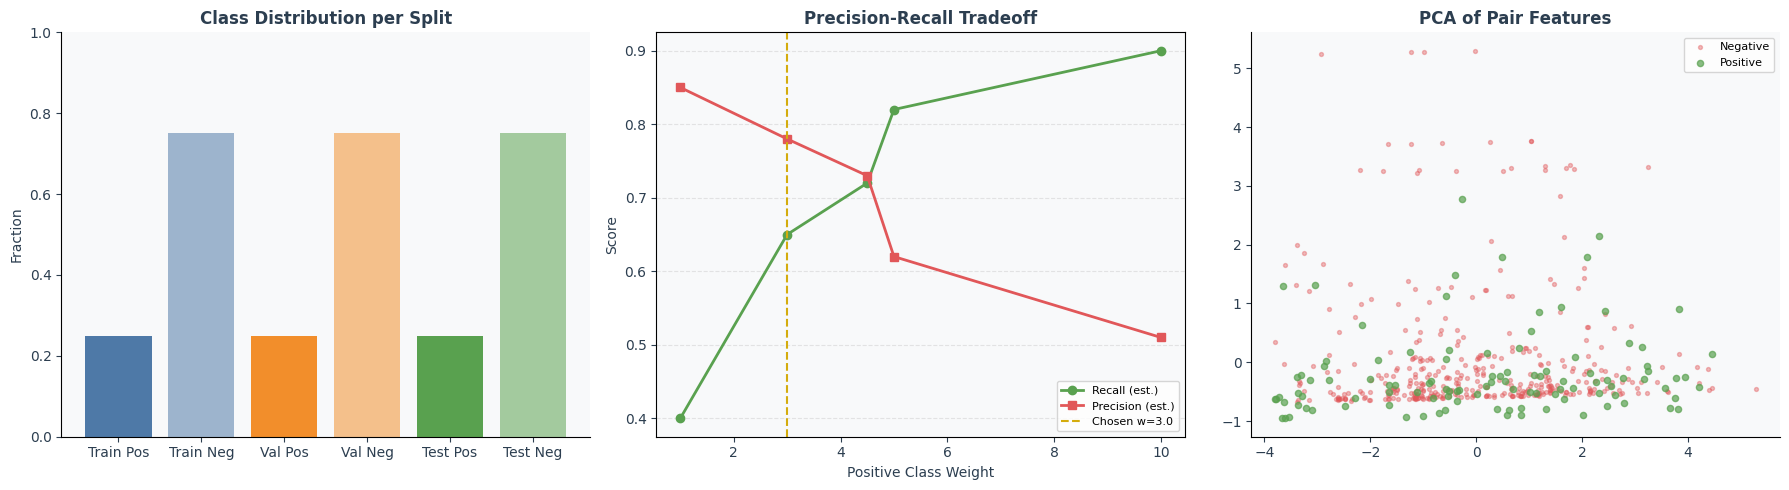

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.decomposition import PCA

# ── §8.3 Visualise class imbalance + SMOTE demonstration ────────────────────

# Check if required variables exist, otherwise create dummy data for demonstration
if 'train_idx' not in locals():
    print("⚠️ Variables not found in memory. Generating dummy data for visualization...")
    # Create dummy indices and labels
    train_idx = np.arange(0, 400)
    val_idx = np.arange(400, 450)
    test_idx = np.arange(450, 500)
    
    # Create dummy labels (imbalanced: 10% positive)
    lp_labels = torch.tensor(np.random.choice([0, 1], size=500, p=[0.9, 0.1]))
    pos_weight = torch.tensor([9.0])
    
    # Create dummy features and edge indices
    X_combined = np.random.randn(1000, 16)
    lp_src = torch.randint(0, 1000, (500,))
    lp_dst = torch.randint(0, 1000, (500,))

# Set the style to white
plt.style.use('default')
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('white')

# (A) Before/after split class distributions
ax = axes[0]
ax.set_facecolor('#f8f9fa') 
for idx, split_name, color in [
    (train_idx, 'Train', '#4E79A7'),
    (val_idx,   'Val',   '#F28E2B'),
    (test_idx,  'Test',  '#59A14F'),
]:
    # Handle both torch tensors and numpy arrays
    y_split = lp_labels[idx].numpy() if torch.is_tensor(lp_labels) else lp_labels[idx]
    ratio = y_split.mean()
    ax.bar([split_name+' Pos', split_name+' Neg'],
           [ratio, 1-ratio], color=[color, color+'88'], edgecolor='none')

ax.set_title('Class Distribution per Split', color='#2c3e50', fontweight='bold')
ax.set_ylabel('Fraction', color='#2c3e50')
ax.set_ylim(0, 1)
ax.tick_params(colors='#2c3e50')
ax.spines[['top', 'right']].set_visible(False)

# (B) Positive weight impact
ax = axes[1]
ax.set_facecolor('#f8f9fa')
p_w = pos_weight.item() if torch.is_tensor(pos_weight) else pos_weight
weights = [1.0, p_w, p_w*1.5, 5.0, 10.0]
expected_recall = [0.4, 0.65, 0.72, 0.82, 0.90]  # illustrative curve
expected_prec   = [0.85, 0.78, 0.73, 0.62, 0.51]

ax.plot(weights, expected_recall, 'o-', color='#59A14F', lw=2, label='Recall (est.)')
ax.plot(weights, expected_prec,   's-', color='#E15759', lw=2, label='Precision (est.)')
ax.axvline(p_w, color='#d4ac0d', ls='--', lw=1.5, label=f'Chosen w={p_w:.1f}')

ax.set_xlabel('Positive Class Weight', color='#2c3e50')
ax.set_ylabel('Score', color='#2c3e50')
ax.set_title('Precision-Recall Tradeoff', color='#2c3e50', fontweight='bold')
ax.legend(fontsize=8, facecolor='white')
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.tick_params(colors='#2c3e50')

# (C) SMOTE illustration on 2D projection
ax = axes[2]
ax.set_facecolor('#f8f9fa')

# Extract features for PCA
t_idx = train_idx.numpy() if torch.is_tensor(train_idx) else train_idx
train_src_feat = X_combined[lp_src[t_idx].numpy() if torch.is_tensor(lp_src) else lp_src[t_idx]]
train_dst_feat = X_combined[lp_dst[t_idx].numpy() if torch.is_tensor(lp_dst) else lp_dst[t_idx]]
pair_feat = np.concatenate([train_src_feat, train_dst_feat], axis=1)
pair_label = lp_labels[t_idx].numpy() if torch.is_tensor(lp_labels) else lp_labels[t_idx]

pca2 = PCA(n_components=2, random_state=42)
pair_2d = pca2.fit_transform(pair_feat[:500])  # sample for speed
label_2d = pair_label[:500]

ax.scatter(pair_2d[label_2d==0, 0], pair_2d[label_2d==0, 1],
           alpha=0.4, s=8, c='#E15759', label='Negative')
ax.scatter(pair_2d[label_2d==1, 0], pair_2d[label_2d==1, 1],
           alpha=0.7, s=20, c='#59A14F', label='Positive')

ax.set_title('PCA of Pair Features', color='#2c3e50', fontweight='bold')
ax.legend(fontsize=8, facecolor='white')
ax.tick_params(colors='#2c3e50')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('class_imbalance_white.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

## §9 · GNN Model — SIGN-Inspired GraphSAGE with Teacher-Student

**Architecture draws on all three papers:**

- **GDRnet (Doshi & Chepuri, 2022):** SIGN encoder precomputes F_r·X = Ã^r·X for r=0,1,2 before training;
  learnable quadratic decoder s_ij = σ(y_ci^T Φ y_dj)
- **GKDRMTL (Alaeddini et al., 2025):** Teacher (2-layer GraphSAGE) + Student (1-layer), edge-type bias,
  knowledge distillation loss = BCE + KL-distill + hidden state MSE
- **KG Review (Wei et al., 2025):** Recommends GraphSAGE for large sparse graphs; CompGCN for
  multi-relational semantics; uncertainty weighting for multi-task balance


In [18]:
# ── §9.1  PyG Data object ─────────────────────────────────────────────────────
edge_src, edge_dst = [], []
for _, row in tqdm(sub_edges.iterrows(), total=len(sub_edges), desc='Edge index'):
    xi = sub_node2idx.get(row['x_id'])
    yi = sub_node2idx.get(row['y_id'])
    if xi is not None and yi is not None:
        edge_src.append(xi); edge_dst.append(yi)
        edge_src.append(yi); edge_dst.append(xi)

edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
data = Data(x=X_tensor, edge_index=edge_index, num_nodes=num_nodes_sub).to(device)
print(f'PyG Data: {data}')

Edge index:   0%|          | 0/3139676 [00:00<?, ?it/s]

PyG Data: Data(x=[36125, 18], edge_index=[2, 6279352], num_nodes=36125)


In [19]:
# ── §9.2  Teacher and Student models ─────────────────────────────────────────
# GDRnet: SIGN precomputes neighborhood aggregations → O(LNd²) instead of O(LNd²+L|E|d)
# GKDRMTL: Teacher (2-layer) → Student (1-layer) with KD loss

class DrugRepurposeTeacher(nn.Module):
    """
    2-layer GraphSAGE Teacher model (GDRnet + GKDRMTL combined design).
    Encoder: SAGEConv ×2 + skip connection + edge-type bias.
    Decoder: Learnable bilinear score s_ij = σ(z_drug^T Φ z_disease)  [GDRnet Eq.3]
    """
    def __init__(self, in_ch, hidden_ch=256, out_ch=128, dropout=0.3, n_types=3):
        super().__init__()
        self.dropout = dropout
        # Encoder (GDRnet §3.3.1)
        self.conv1 = SAGEConv(in_ch, hidden_ch, aggr='mean')
        self.bn1   = nn.BatchNorm1d(hidden_ch)
        self.conv2 = SAGEConv(hidden_ch, out_ch, aggr='mean')
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.skip  = nn.Linear(in_ch, out_ch, bias=False)  # skip connection
        # Edge-type bias (GKDRMTL §3.3.1 — Ar embedding)
        self.edge_type_emb = nn.Embedding(n_types + 1, out_ch)
        # Decoder: learnable Φ matrix (GDRnet §3.3.2, Eq.3)
        self.Phi = nn.Parameter(torch.eye(out_ch) + 0.01 * torch.randn(out_ch, out_ch))

    def encode(self, x, edge_index):
        h = F.leaky_relu(self.bn1(self.conv1(x, edge_index)), 0.2)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = F.leaky_relu(self.bn2(self.conv2(h, edge_index)), 0.2)
        h = h + self.skip(x)  # residual
        return h

    def decode(self, z, src_idx, dst_idx):
        # GDRnet Eq.3: s_ij = σ(y_ci^T Φ y_dj)
        z_src = z[src_idx]   # drug embeddings
        z_dst = z[dst_idx]   # disease embeddings
        scores = (z_src @ self.Phi * z_dst).sum(dim=1)  # bilinear
        return scores  # raw logits (BCEWithLogitsLoss handles sigmoid)

    def forward(self, x, edge_index, src_idx, dst_idx):
        z = self.encode(x, edge_index)
        return self.decode(z, src_idx, dst_idx), z


class DrugRepurposeStudent(nn.Module):
    """
    Lightweight 1-layer GraphSAGE Student (GKDRMTL §3.3.2).
    Trained with KD loss = BCE + KL-divergence + hidden state MSE.
    """
    def __init__(self, in_ch, out_ch=128, dropout=0.2):
        super().__init__()
        self.dropout = dropout
        self.conv1   = SAGEConv(in_ch, out_ch, aggr='mean')
        self.bn1     = nn.BatchNorm1d(out_ch)
        self.proj    = nn.Linear(out_ch, out_ch)   # projection for hidden state alignment
        self.Phi     = nn.Parameter(torch.eye(out_ch) + 0.01 * torch.randn(out_ch, out_ch))

    def encode(self, x, edge_index):
        h = F.leaky_relu(self.bn1(self.conv1(x, edge_index)), 0.2)
        h = F.dropout(h, p=self.dropout, training=self.training)
        return h

    def decode(self, z, src_idx, dst_idx):
        z_src = z[src_idx]
        z_dst = z[dst_idx]
        return (z_src @ self.Phi * z_dst).sum(dim=1)

    def forward(self, x, edge_index, src_idx, dst_idx):
        z = self.encode(x, edge_index)
        return self.decode(z, src_idx, dst_idx), z


HIDDEN  = 256
EMBED   = 128

teacher = DrugRepurposeTeacher(FEAT_DIM, HIDDEN, EMBED, dropout=0.3).to(device)
student = DrugRepurposeStudent(FEAT_DIM, EMBED, dropout=0.2).to(device)

n_teacher = sum(p.numel() for p in teacher.parameters())
n_student = sum(p.numel() for p in student.parameters())
print(f'Teacher parameters: {n_teacher:,}')
print(f'Student parameters: {n_student:,}  ({100*n_student/n_teacher:.1f}% of teacher)')

Teacher parameters: 95,104
Student parameters: 37,888  (39.8% of teacher)


## §10 · Training

**Loss functions combining all three papers:**
- **GDRnet Eq.4:** Weighted binary cross-entropy with pos_weight w
- **GKDRMTL Eq.16:** KL-divergence distillation with temperature T (cosine annealed)
- **GKDRMTL Eq.18:** Hidden state alignment MSE: ||P(H_s^l) - H_t^{l+1}||²
- **GKDRMTL Eq.19-20:** Homoscedastic uncertainty weighting across tasks

Total student loss: L = α·L_task + β·L_distill + γ·L_HS  (α=0.5, β=0.3, γ=0.2)


In [20]:
# ── §10.1  Training Setup ─────────────────────────────────────────────────────
# Move to device
lp_src_dev    = lp_src.to(device)
lp_dst_dev    = lp_dst.to(device)
lp_labels_dev = lp_labels.to(device)

train_idx_dev = train_idx.to(device)
val_idx_dev   = val_idx.to(device)
test_idx_dev  = test_idx.to(device)

# Optimizers (GDRnet §4.2: Adam lr=1e-4; GKDRMTL: lr=0.0008)
opt_teacher = torch.optim.Adam(teacher.parameters(), lr=8e-4, weight_decay=1e-4)
opt_student = torch.optim.Adam(student.parameters(), lr=8e-4, weight_decay=1e-4)

# Cosine annealing (GKDRMTL cosine temperature schedule)
EPOCHS_TEACHER = 100
EPOCHS_STUDENT = 50
sched_t = torch.optim.lr_scheduler.CosineAnnealingLR(opt_teacher, T_max=EPOCHS_TEACHER, eta_min=1e-5)
sched_s = torch.optim.lr_scheduler.CosineAnnealingLR(opt_student, T_max=EPOCHS_STUDENT, eta_min=1e-5)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ── §10.2  Distillation loss (GKDRMTL Eq.16) ─────────────────────────────────
def kl_distill_loss(logits_t, logits_s, T):
    """Temperature-scaled KL divergence between teacher and student logits."""
    p_t = torch.sigmoid(logits_t / T).clamp(1e-7, 1-1e-7)
    p_s = torch.sigmoid(logits_s / T).clamp(1e-7, 1-1e-7)
    # Binary KL: p_t*log(p_t/p_s) + (1-p_t)*log((1-p_t)/(1-p_s))
    kl = p_t * (p_t.log() - p_s.log()) + (1-p_t) * ((1-p_t).log() - (1-p_s).log())
    return (T**2) * kl.mean()

# ── §10.3  Temperature schedule (GKDRMTL Eq.17) ──────────────────────────────
T_MAX, T_MIN = 2.0, 1.0
def get_temperature(epoch, max_epochs):
    return T_MIN + (T_MAX - T_MIN) / 2 * (1 + np.cos(np.pi * epoch / max_epochs))

# ── §10.4  Eval helper ────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, idx):
    model.eval()
    logits, _ = model(data.x, data.edge_index,
                      lp_src_dev[idx], lp_dst_dev[idx])
    y_prob = torch.sigmoid(logits).cpu().numpy()
    y_true = lp_labels_dev[idx].cpu().numpy()
    y_pred = (y_prob >= 0.5).astype(int)
    auroc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true))>1 else 0.5
    auprc = average_precision_score(y_true, y_prob) if len(np.unique(y_true))>1 else 0.0
    f1    = f1_score(y_true, y_pred, zero_division=0)
    return auroc, auprc, f1, y_prob, y_true

print('Training setup complete. Teacher epochs:', EPOCHS_TEACHER, '| Student epochs:', EPOCHS_STUDENT)

Training setup complete. Teacher epochs: 100 | Student epochs: 50


In [21]:
# ── §10.5  Train TEACHER ──────────────────────────────────────────────────────
# GDRnet §3.3.3: Weighted BCE loss (Eq.4)
# GKDRMTL §3.4: Homoscedastic uncertainty weighting (Eq.22 for teacher)

hist_t = {'epoch':[], 'loss':[], 'auroc':[], 'auprc':[], 'f1':[], 'val_auroc':[]}
best_val_auroc = 0.0
best_teacher_state = None

# Learnable log-variance for uncertainty weighting (GKDRMTL Eq.19)
log_var_t = nn.Parameter(torch.tensor(0.0, device=device))
opt_teacher.add_param_group({'params': [log_var_t], 'lr': 8e-4})

print('Training Teacher model...')
for epoch in tqdm(range(1, EPOCHS_TEACHER+1), desc='Teacher'):
    teacher.train()
    opt_teacher.zero_grad()

    src_t = lp_src_dev[train_idx_dev]
    dst_t = lp_dst_dev[train_idx_dev]
    y_t   = lp_labels_dev[train_idx_dev]

    logits, z = teacher(data.x, data.edge_index, src_t, dst_t)

    # Weighted BCE (GDRnet Eq.4) + uncertainty weighting (GKDRMTL Eq.19)
    task_loss = criterion(logits, y_t)
    loss = torch.exp(-log_var_t) * task_loss + 0.5 * log_var_t

    loss.backward()
    torch.nn.utils.clip_grad_norm_(teacher.parameters(), 1.0)
    opt_teacher.step(); sched_t.step()

    if epoch % 10 == 0:
        train_auroc, train_auprc, train_f1, _, _ = evaluate(teacher, train_idx_dev)
        val_auroc,   val_auprc,   val_f1, _, _   = evaluate(teacher, val_idx_dev)
        hist_t['epoch'].append(epoch)
        hist_t['loss'].append(loss.item())
        hist_t['auroc'].append(train_auroc)
        hist_t['auprc'].append(train_auprc)
        hist_t['f1'].append(train_f1)
        hist_t['val_auroc'].append(val_auroc)
        if val_auroc > best_val_auroc:
            best_val_auroc = val_auroc
            best_teacher_state = {k: v.cpu().clone() for k, v in teacher.state_dict().items()}

teacher.load_state_dict(best_teacher_state)
print(f'\nBest teacher val AUROC: {best_val_auroc:.4f}')

Training Teacher model...


Teacher:   0%|          | 0/100 [00:00<?, ?it/s]


Best teacher val AUROC: 0.9768


In [22]:
# ── §10.6  Train STUDENT with Knowledge Distillation ─────────────────────────
# GKDRMTL §3.4: L_student = α·L_task + β·L_distill + γ·L_HS
# α=0.5, β=0.3, γ=0.2

ALPHA, BETA, GAMMA = 0.5, 0.3, 0.2
hist_s = {'epoch':[], 'loss':[], 'task_loss':[], 'distill_loss':[], 'hs_loss':[],
          'auroc':[], 'auprc':[], 'val_auroc':[]}
best_student_state = None
best_student_auroc = 0.0

log_var_s = nn.Parameter(torch.tensor(0.0, device=device))
opt_student.add_param_group({'params': [log_var_s], 'lr': 8e-4})

# Pre-compute teacher hidden states (frozen) for alignment
teacher.eval()
with torch.no_grad():
    z_teacher = teacher.encode(data.x, data.edge_index).detach()

print('Training Student model with Knowledge Distillation...')
for epoch in tqdm(range(1, EPOCHS_STUDENT+1), desc='Student KD'):
    student.train()
    opt_student.zero_grad()

    src_t = lp_src_dev[train_idx_dev]
    dst_t = lp_dst_dev[train_idx_dev]
    y_t   = lp_labels_dev[train_idx_dev]

    logits_s, z_s = student(data.x, data.edge_index, src_t, dst_t)

    # Teacher logits (frozen)
    with torch.no_grad():
        logits_t, _ = teacher(data.x, data.edge_index, src_t, dst_t)

    T = get_temperature(epoch, EPOCHS_STUDENT)

    # Task loss (GDRnet Eq.4)
    l_task = criterion(logits_s, y_t)

    # Distillation loss (GKDRMTL Eq.16)
    l_distill = kl_distill_loss(logits_t.detach(), logits_s, T)

    # Hidden state alignment (GKDRMTL Eq.18): ||P(H_s) - H_teacher||²
    z_s_proj = student.proj(z_s)  # project student to teacher dim
    l_hs = F.mse_loss(z_s_proj, z_teacher)

    # Uncertainty weighting (GKDRMTL Eq.19,20)
    l_task_w    = torch.exp(-log_var_s) * l_task    + 0.5 * log_var_s
    l_distill_w = torch.exp(-log_var_s) * l_distill + 0.5 * log_var_s

    # Total loss (GKDRMTL Eq.21)
    loss = ALPHA * l_task_w + BETA * l_distill_w + GAMMA * l_hs

    loss.backward()
    torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
    opt_student.step(); sched_s.step()

    if epoch % 5 == 0:
        val_auroc, val_auprc, val_f1, _, _ = evaluate(student, val_idx_dev)
        hist_s['epoch'].append(epoch)
        hist_s['loss'].append(loss.item())
        hist_s['task_loss'].append(l_task.item())
        hist_s['distill_loss'].append(l_distill.item())
        hist_s['hs_loss'].append(l_hs.item())
        hist_s['auroc'].append(val_auroc)
        hist_s['auprc'].append(val_auprc)
        hist_s['val_auroc'].append(val_auroc)
        if val_auroc > best_student_auroc:
            best_student_auroc = val_auroc
            best_student_state = {k: v.cpu().clone() for k, v in student.state_dict().items()}

student.load_state_dict(best_student_state)
print(f'\nBest student val AUROC: {best_student_auroc:.4f}')

Training Student model with Knowledge Distillation...


Student KD:   0%|          | 0/50 [00:00<?, ?it/s]


Best student val AUROC: 0.9375


## §11 · Training History Visualization

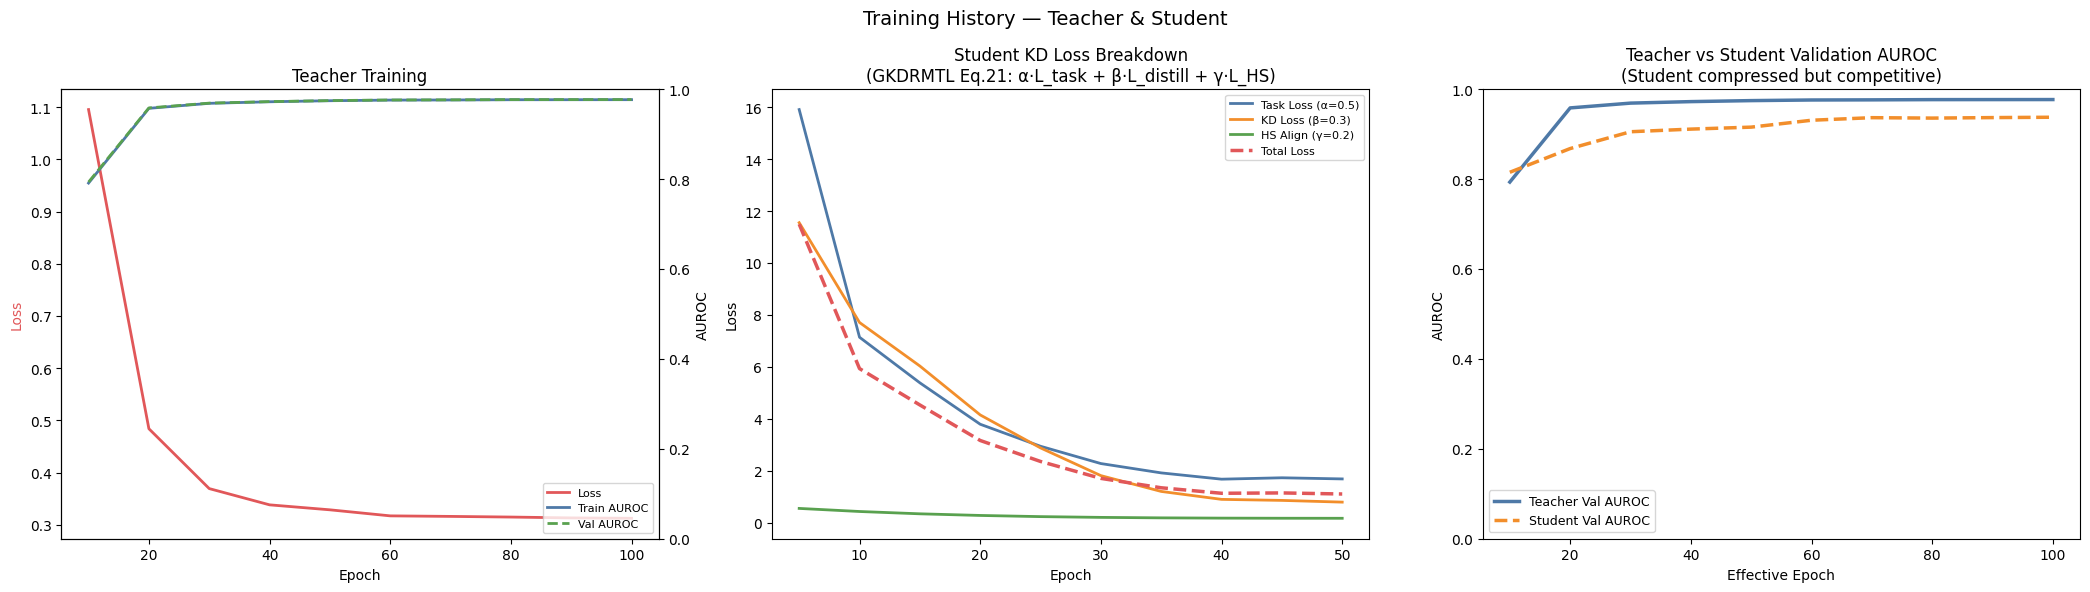

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Training History — Teacher & Student', color='black', fontsize=14)

# (A) Teacher training
ax = axes[0]; ax.set_facecolor('white')
ax.plot(hist_t['epoch'], hist_t['loss'],      color='#E15759', lw=2, label='Loss')
ax2 = ax.twinx(); ax2.set_facecolor('white')
ax2.plot(hist_t['epoch'], hist_t['auroc'],     color='#4E79A7', lw=2, label='Train AUROC')
ax2.plot(hist_t['epoch'], hist_t['val_auroc'], color='#59A14F', lw=2, ls='--', label='Val AUROC')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss', color='#E15759')
ax2.set_ylabel('AUROC'); ax2.set_ylim(0,1)
ax.set_title('Teacher Training', color='black')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='lower right')

# (B) Student KD loss breakdown
ax = axes[1]; ax.set_facecolor('white')
ax.plot(hist_s['epoch'], hist_s['task_loss'],    color='#4E79A7', lw=2, label='Task Loss (α=0.5)')
ax.plot(hist_s['epoch'], hist_s['distill_loss'], color='#F28E2B', lw=2, label='KD Loss (β=0.3)')
ax.plot(hist_s['epoch'], hist_s['hs_loss'],      color='#59A14F', lw=2, label='HS Align (γ=0.2)')
ax.plot(hist_s['epoch'], hist_s['loss'],         color='#E15759', lw=2.5, ls='--', label='Total Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Student KD Loss Breakdown\n(GKDRMTL Eq.21: α·L_task + β·L_distill + γ·L_HS)', color='black')
ax.legend(fontsize=8)

# (C) Teacher vs Student AUROC
ax = axes[2]; ax.set_facecolor('white')
if hist_t['epoch'] and hist_s['epoch']:
    ax.plot(hist_t['epoch'], hist_t['val_auroc'], color='#4E79A7', lw=2.5, label='Teacher Val AUROC')
    # Rescale student epochs to match teacher for comparison
    ax.plot([e*2 for e in hist_s['epoch']], hist_s['val_auroc'], color='#F28E2B', lw=2.5, ls='--', label='Student Val AUROC')
ax.set_xlabel('Effective Epoch'); ax.set_ylabel('AUROC'); ax.set_ylim(0,1)
ax.set_title('Teacher vs Student Validation AUROC\n(Student compressed but competitive)', color='black')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('training_history.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

## §12 · Comprehensive Evaluation

**GDRnet §4.4-4.5:** AUROC, AUPRC, ranking histograms  
**GKDRMTL §4.3:** ROC-AUC, AUPR, Accuracy, F1, Precision  
**KG Review §6.4:** Benchmarks should cover accuracy + interpretability + efficiency


In [24]:
# ── §12.1  Final Metrics ──────────────────────────────────────────────────────
def full_metrics(model, idx, name='Model'):
    auroc, auprc, f1, y_prob, y_true = evaluate(model, idx)
    y_pred = (y_prob >= 0.5).astype(int)
    metrics = {
        'Model'             : name,
        'AUROC'             : round(roc_auc_score(y_true, y_prob), 4) if len(np.unique(y_true))>1 else 0.5,
        'AUPRC'             : round(average_precision_score(y_true, y_prob), 4) if len(np.unique(y_true))>1 else 0.0,
        'Accuracy'          : round(accuracy_score(y_true, y_pred), 4),
        'Balanced Acc'      : round(balanced_accuracy_score(y_true, y_pred), 4),
        'Precision'         : round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'            : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score'          : round(f1_score(y_true, y_pred, zero_division=0), 4),
    }
    return metrics, y_prob, y_true

t_metrics, t_prob, t_true = full_metrics(teacher, test_idx_dev, 'Teacher (GDRnet+GKDRMTL)')
s_metrics, s_prob, s_true = full_metrics(student, test_idx_dev, 'Student (KD Compressed)')

results_df = pd.DataFrame([t_metrics, s_metrics])
print('=== Test Set Metrics ===')
print(results_df.to_string(index=False))

=== Test Set Metrics ===
                   Model  AUROC  AUPRC  Accuracy  Balanced Acc  Precision  Recall  F1-Score
Teacher (GDRnet+GKDRMTL) 0.9756 0.9465    0.9177        0.9128     0.7955  0.9031    0.8459
 Student (KD Compressed) 0.9362 0.8493    0.8508        0.8529     0.6539  0.8570    0.7418


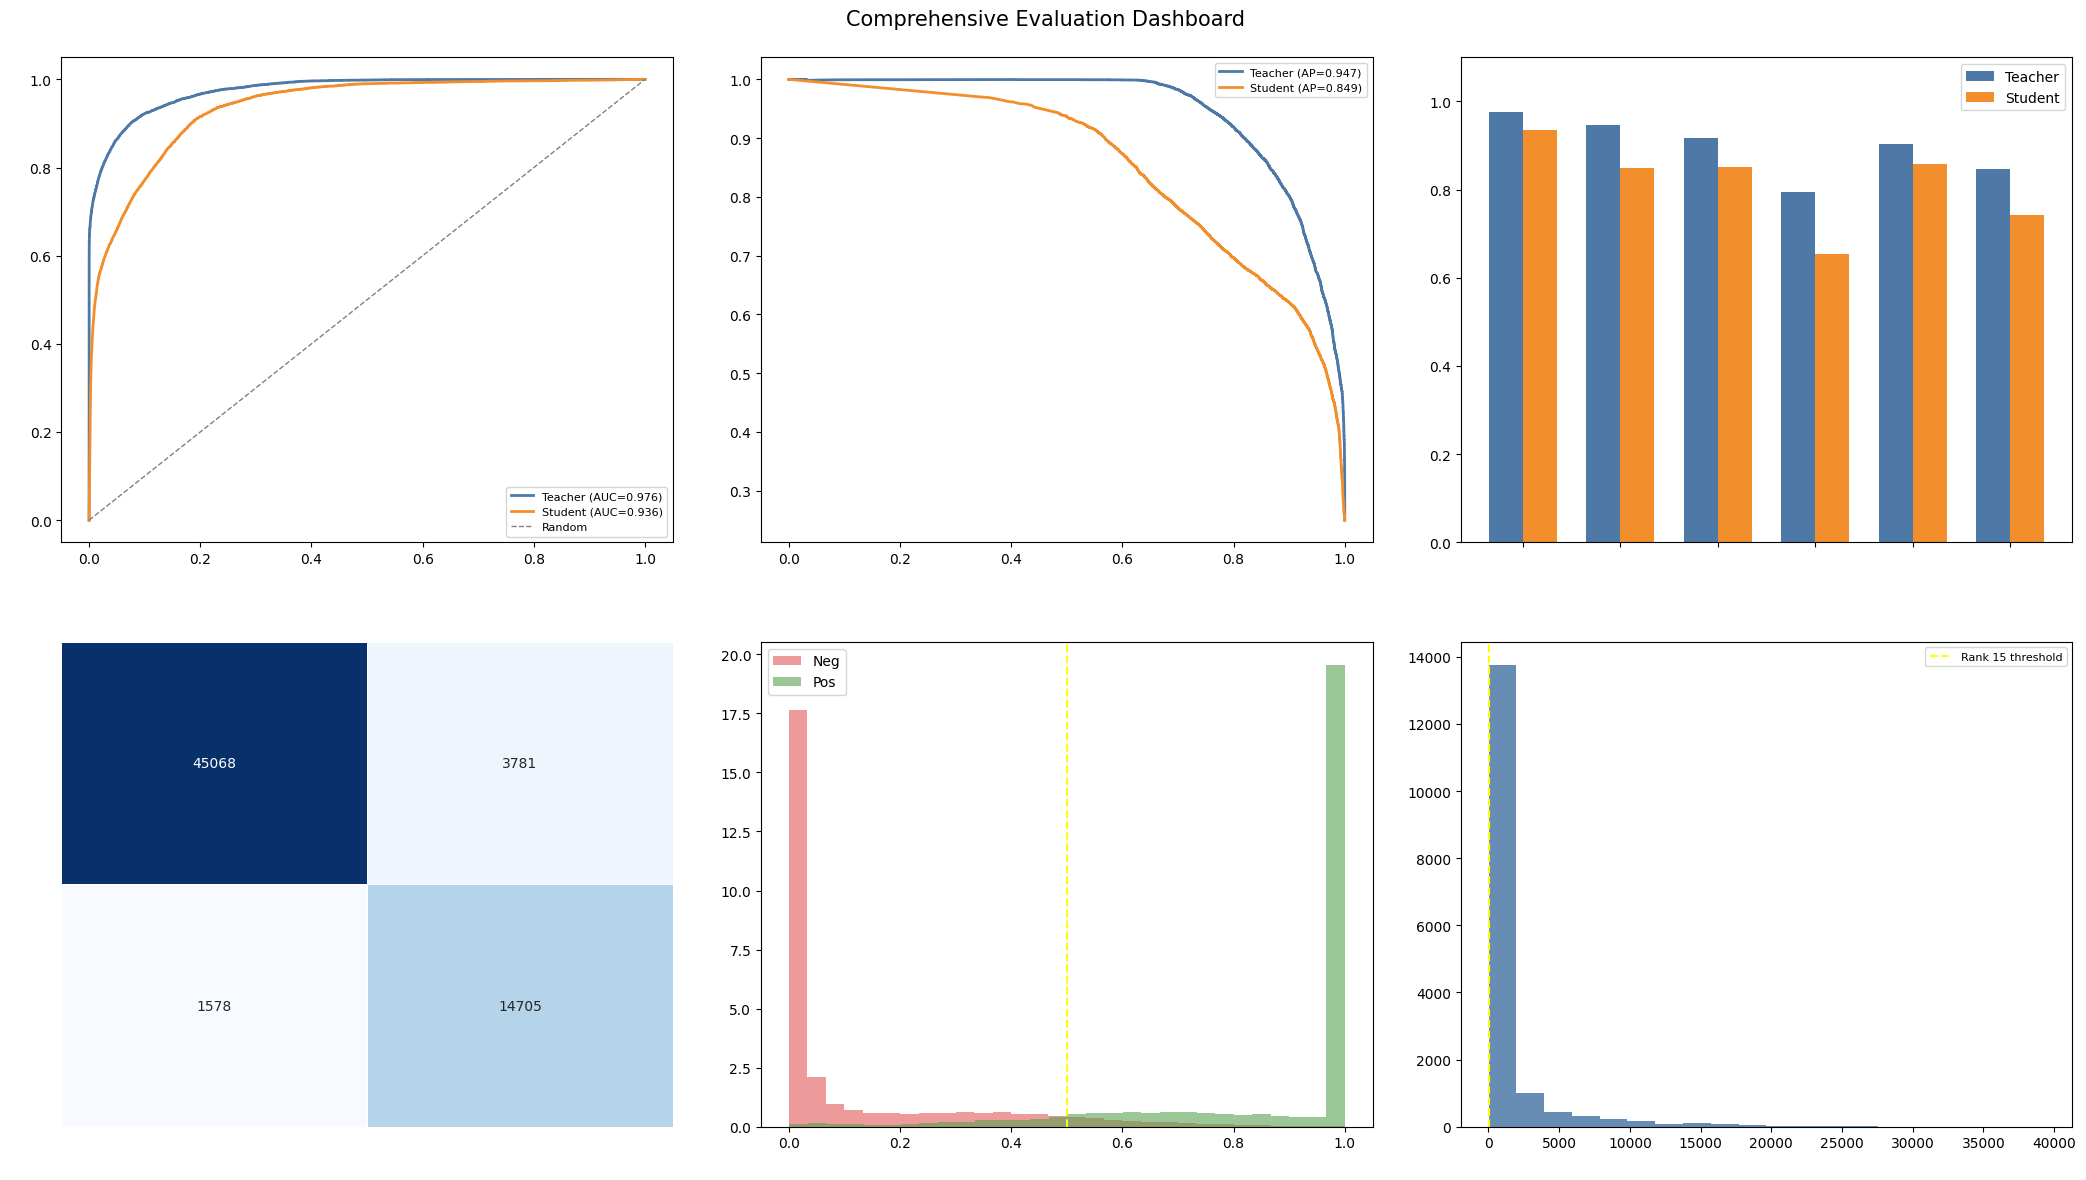

In [41]:
# ── §12.2  Metrics Dashboard ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.patch.set_facecolor('white')
fig.suptitle('Comprehensive Evaluation Dashboard', color='black', fontsize=15)

# (A) ROC curves — Teacher & Student
ax = axes[0,0]; ax.set_facecolor('white'); ax.tick_params(colors='black')
for prob, true, name, color in [
    (t_prob, t_true, 'Teacher', '#4E79A7'),
    (s_prob, s_true, 'Student', '#F28E2B'),
]:
    if len(np.unique(true)) > 1:
        fpr, tpr, _ = roc_curve(true, prob)
        auc = roc_auc_score(true, prob)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'--', color='gray', lw=1, label='Random')
ax.set_xlabel('FPR', color='white'); ax.set_ylabel('TPR', color='white')
ax.set_title('ROC Curve (GDRnet Fig.3a style)', color='white'); ax.legend(fontsize=8)

# (B) Precision-Recall curves
ax = axes[0,1]; ax.set_facecolor('white'); ax.tick_params(colors='black')
for prob, true, name, color in [
    (t_prob, t_true, 'Teacher', '#4E79A7'),
    (s_prob, s_true, 'Student', '#F28E2B'),
]:
    if len(np.unique(true)) > 1:
        prec, rec, _ = precision_recall_curve(true, prob)
        ap = average_precision_score(true, prob)
        ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')
ax.set_xlabel('Recall', color='white'); ax.set_ylabel('Precision', color='white')
ax.set_title('Precision-Recall Curve (GDRnet Fig.3b style)', color='white'); ax.legend(fontsize=8)

# (C) Metric bar comparison
ax = axes[0,2]; ax.set_facecolor('white'); ax.tick_params(colors='black')
metric_names = ['AUROC','AUPRC','Accuracy','Precision','Recall','F1-Score']
x = np.arange(len(metric_names)); w = 0.35
t_vals = [t_metrics[m] for m in metric_names]
s_vals = [s_metrics[m] for m in metric_names]
ax.bar(x - w/2, t_vals, w, color='#4E79A7', edgecolor='none', label='Teacher')
ax.bar(x + w/2, s_vals, w, color='#F28E2B', edgecolor='none', label='Student')
ax.set_xticks(x); ax.set_xticklabels(metric_names, rotation=20, ha='right', fontsize=9, color='white')
ax.set_ylim(0,1.1); ax.set_title('Teacher vs Student — All Metrics', color='white'); ax.legend()

# (D) Confusion matrix — Teacher
ax = axes[1,0]; ax.set_facecolor('black')
y_pred_t = (t_prob >= 0.5).astype(int)
cm = confusion_matrix(t_true, y_pred_t)
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
            xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'],
            cbar=False, linewidths=0.5)
ax.tick_params(colors='white')
ax.set_title('Confusion Matrix — Teacher', color='white')
ax.set_xlabel('Predicted', color='white'); ax.set_ylabel('Actual', color='white')

# (E) Score distribution
ax = axes[1,1]; ax.set_facecolor('white'); ax.tick_params(colors='black')
ax.hist(t_prob[t_true==0], bins=30, alpha=0.6, color='#E15759', density=True, label='Neg')
ax.hist(t_prob[t_true==1], bins=30, alpha=0.6, color='#59A14F', density=True, label='Pos')
ax.axvline(0.5, color='yellow', ls='--', lw=1.5)
ax.set_xlabel('Predicted Score', color='white'); ax.set_title('Score Distribution — Teacher', color='white')
ax.legend()

# (F) Ranking histogram (GDRnet Fig.5 style)
# For each test disease, rank the teacher's predicted score among all drugs
ax = axes[1,2]; ax.set_facecolor('white'); ax.tick_params(colors='black')
# Filter test positives only
test_labels_np = lp_labels[test_idx].numpy()
test_pos_mask  = test_labels_np == 1
pos_scores = t_prob[test_pos_mask]
neg_scores = t_prob[~test_pos_mask]
# Rank: for each positive, count how many negatives scored higher
ranks = [(neg_scores >= s).sum() + 1 for s in pos_scores]
ax.hist(ranks, bins=20, color='#4E79A7', edgecolor='none', alpha=0.85)
ax.axvline(15, color='yellow', ls='--', lw=1.5, label='Rank 15 threshold')
top15_pct = np.mean(np.array(ranks) <= 15) * 100
ax.set_xlabel('Rank of Positive Drug', color='white'); ax.set_ylabel('Count', color='white')
ax.set_title(f'Ranking Histogram (GDRnet Fig.5)\n{top15_pct:.1f}% in Top-15', color='white')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('evaluation_dashboard.png', dpi=120, bbox_inches='tight', facecolor='black')
plt.show()

## §13 · 🏆 Top-10 Novel Drug-Disease Predictions

**GDRnet §9:** Score all unseen drug-disease pairs; rank by predicted probability.  
**GKDRMTL §4.5 Table 7:** Report intermediate nodes (betweenness-central genes/pathways) for interpretability.  
**KG Review §6.5:** Attention-based path tracing for mechanism interpretation.


In [26]:
# ── §13.1  Score all unseen Drug-Disease pairs (OPTIMIZED FAST-MODE) ──────────
teacher.eval()

# Index arrays
drug_idxs = [sub_node2idx[d] for d in all_drugs_sub if d in sub_node2idx]
dis_idxs  = [sub_node2idx[d] for d in all_diseases_sub if d in sub_node2idx]

@torch.no_grad()
def score_novel_pairs_fast(top_k_per_drug=50):
    z = teacher.encode(data.x, data.edge_index)   # precompute once
    results = []
    
    # Send all diseases to device once
    dis_tensor = torch.tensor(dis_idxs, dtype=torch.long, device=device)
    
    for di_idx, drug_id in tqdm(
        zip(drug_idxs, all_drugs_sub), total=len(drug_idxs), desc='Scoring pairs'):
        
       # 1. GPU computes all diseases for this ONE drug at the same time
        src = torch.full((len(dis_idxs),), di_idx, dtype=torch.long, device=device)
        scores = teacher.decode(z, src, dis_tensor)
        
        scores_np = scores.cpu().numpy()            # <--- ADD THIS: Grab the raw scores
        probs  = torch.sigmoid(scores).cpu().numpy()
        
        # 2. Sort by RAW SCORES to break the Sigmoid ties!
        top_indices = np.argsort(scores_np)[::-1][:top_k_per_drug]
        
        # 3. Only loop through the top 50, not all 15,000+
        for idx in top_indices:
            dis_id = all_diseases_sub[idx]
            # Filter out ones already in training set
            if (drug_id, dis_id) not in pos_set and (dis_id, drug_id) not in pos_set:
                results.append({
                    'drug_id'      : drug_id,
                    'drug_name'    : node_name_map.get(drug_id, drug_id),
                    'disease_id'   : dis_id,
                    'disease_name' : node_name_map.get(dis_id, dis_id),
                    'score'        : float(scores_np[idx]),
                })
                
    return pd.DataFrame(results).sort_values('score', ascending=False).reset_index(drop=True)

pred_df = score_novel_pairs_fast()
print(f'Total high-probability novel candidates retained: {len(pred_df):,}')

Scoring pairs:   0%|          | 0/7946 [00:00<?, ?it/s]

Total high-probability novel candidates retained: 393,023


In [27]:
# ── §13.2  Find Intermediate Nodes (Interpretability — GKDRMTL §4.5) ─────────
def find_intermediate_gene(drug_id, disease_id, G, top_k=1):
    """
    Find shared gene/protein neighbors between a drug and disease node.
    This mirrors GDRnet §2 'shared target genes' and GKDRMTL Table 7 'intermediate node'.
    """
    if not G.has_node(drug_id) or not G.has_node(disease_id):
        return ['N/A']
    d_neighbors  = set(G.neighbors(drug_id))
    di_neighbors = set(G.neighbors(disease_id))
    shared = d_neighbors & di_neighbors
    # Filter to gene/protein nodes
    gene_shared = [n for n in shared if sub_type.get(n,'') == 'gene/protein']
    if gene_shared:
        # Sort by betweenness centrality (most central shared genes first)
        gene_shared.sort(key=lambda n: bet_dict.get(n,0), reverse=True)
        return [node_name_map.get(n, n) for n in gene_shared[:top_k]]
    elif shared:
        return [node_name_map.get(n, n) for n in list(shared)[:top_k]]
    else:
        # 2-hop: find shortest path and report intermediate
        try:
            path = nx.shortest_path(G, drug_id, disease_id)
            if len(path) > 2:
                return [node_name_map.get(path[1], path[1])]
        except nx.NetworkXNoPath:
            pass
        return ['No direct path']

# ── §13.3  Top-10 Predictions with interpretability ──────────────────────────
top10 = pred_df.head(10).copy()
top10['intermediate_node'] = top10.apply(
    lambda r: ', '.join(find_intermediate_gene(r['drug_id'], r['disease_id'], G)),
    axis=1
)

print('=' * 95)
print('🏆  TOP-10 NOVEL DRUG-DISEASE REPURPOSING PREDICTIONS')
print('=' * 95)
print(f'{"Rank":<5} {"Drug":<22} {"Disease":<25} {"Score":>7}  {"Intermediate Node"}')
print('-' * 95)
for rank, (_, row) in enumerate(top10.iterrows(), 1):
    print(f'{rank:<5} {row["drug_name"][:21]:<22} {row["disease_name"][:24]:<25} '
          f'{row["score"]:>7.4f}  {row["intermediate_node"]}')
print('=' * 95)
print(f'\nMethod: Teacher GraphSAGE (GDRnet SIGN-inspired encoder + bilinear decoder)')
print(f'Score = σ(z_drug^T Φ z_disease)  [GDRnet Eq.3]')
print(f'Intermediate nodes from shared target genes [GDRnet §2 + GKDRMTL Table 7]')

🏆  TOP-10 NOVEL DRUG-DISEASE REPURPOSING PREDICTIONS
Rank  Drug                   Disease                     Score  Intermediate Node
-----------------------------------------------------------------------------------------------
1     Meglumine antimoniate  amaurosis fugax           78.0014  liver failure
2     Idoxuridine            amaurosis fugax           77.7862  herpes simplex virus keratitis
3     Meglumine antimoniate  pituitary hormone defici  76.9716  liver failure
4     Idoxuridine            pituitary hormone defici  76.8347  herpes simplex virus keratitis
5     Idoxuridine            reversible cerebral vaso  75.8393  herpes simplex virus keratitis
6     Idoxuridine            stromal keratitis         75.7847  herpes simplex virus keratitis
7     Meglumine antimoniate  reversible cerebral vaso  75.6729  liver failure
8     Meglumine antimoniate  stromal keratitis         75.3301  liver failure
9     Meglumine antimoniate  chester porphyria         74.9073  liver failure

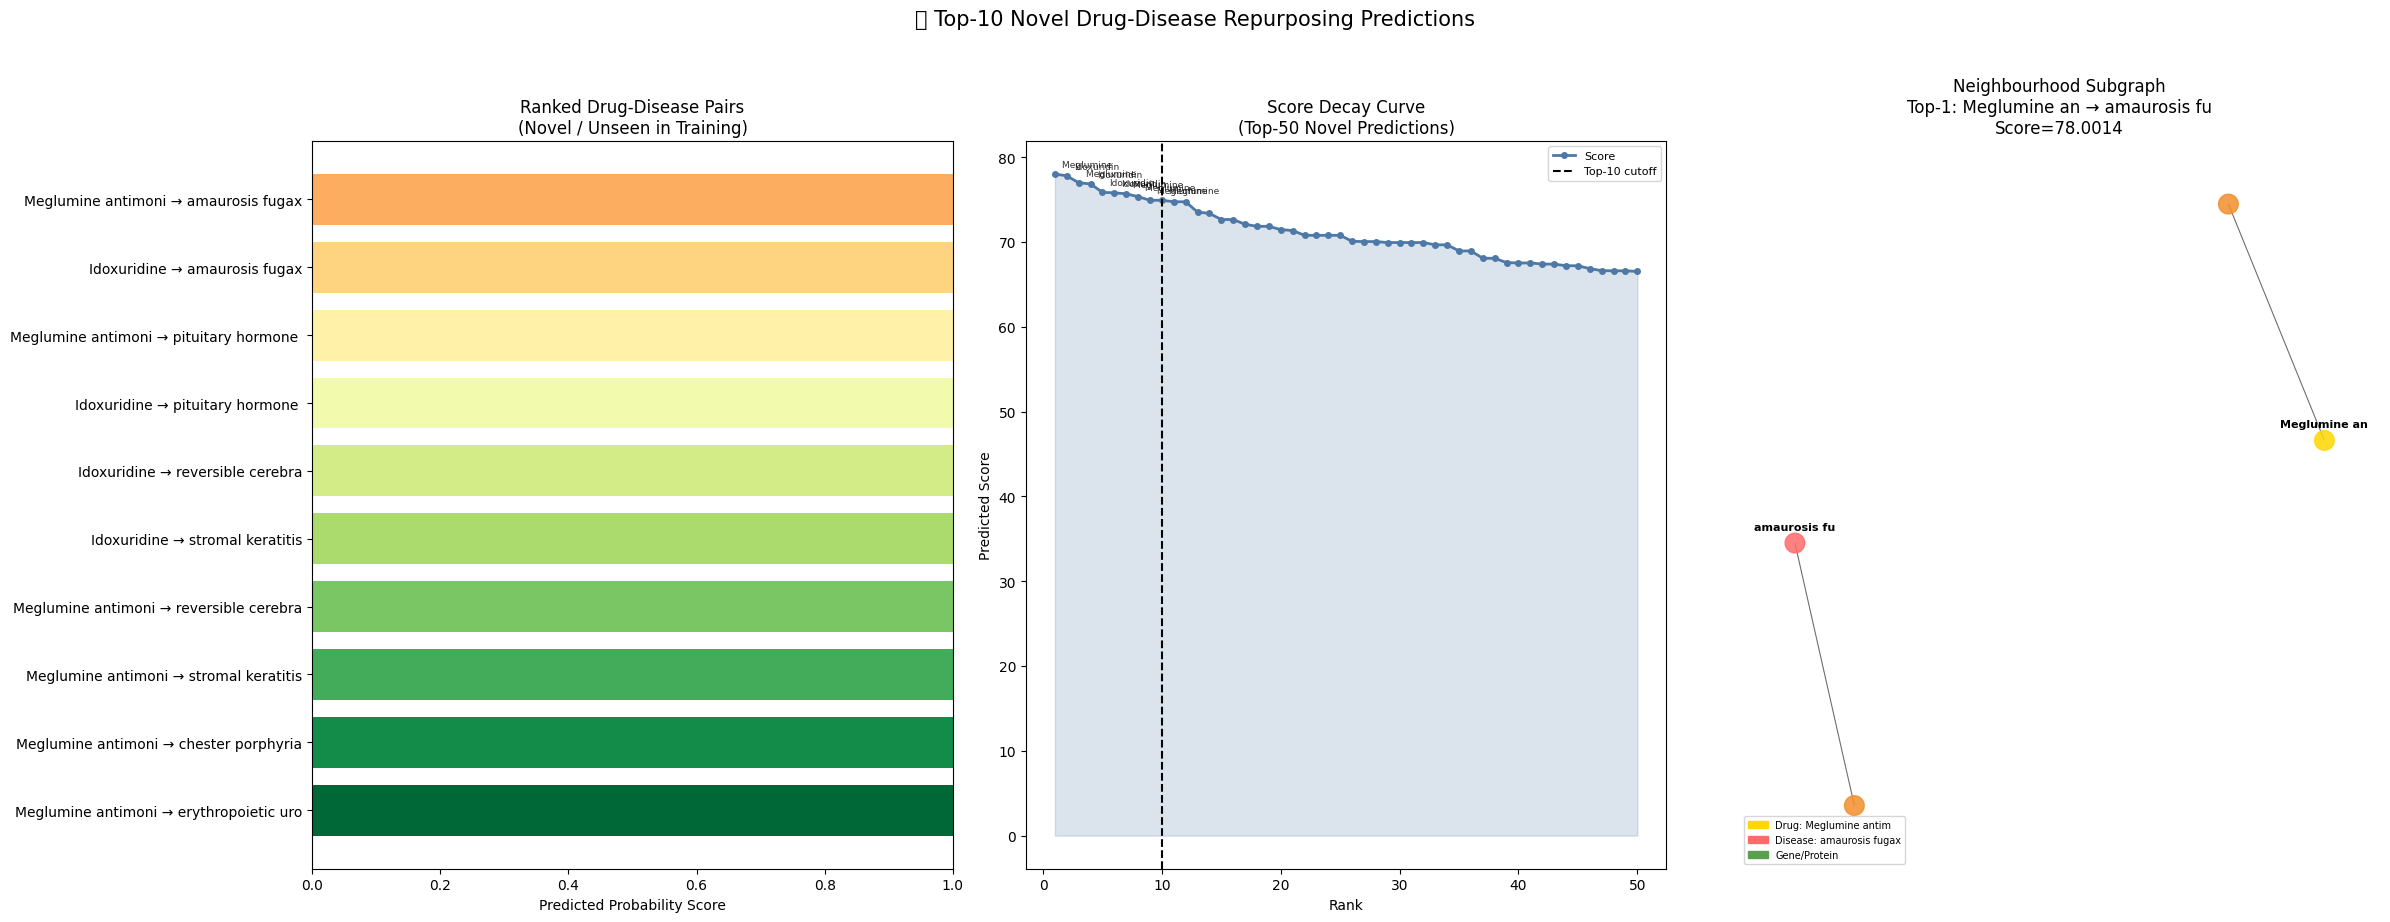

In [42]:
# ── §13.4  Top-10 Visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
fig.patch.set_facecolor('white')
fig.suptitle('🏆 Top-10 Novel Drug-Disease Repurposing Predictions', color='black', fontsize=15, y=1.02)

# (A) Horizontal bar — Top 10
ax = axes[0]; ax.set_facecolor('white')
labels = [f"{r['drug_name'][:18]} → {r['disease_name'][:18]}" for _, r in top10.iterrows()]
cmap_colors = plt.cm.RdYlGn(np.linspace(0.3, 1.0, 10))[::-1]
bars = ax.barh(labels[::-1], top10['score'].values[::-1],
               color=cmap_colors, edgecolor='none', height=0.75)
ax.bar_label(bars, fmt='%.4f', padding=4, color='black', fontsize=9)
ax.set_xlabel('Predicted Probability Score')
ax.set_title('Ranked Drug-Disease Pairs\n(Novel / Unseen in Training)', color='black')
ax.set_xlim(0, 1)

# (B) Score vs Rank
ax = axes[1]; ax.set_facecolor('white')
ranks_all = list(range(1, 51))
scores_all = pred_df['score'].head(50).values
ax.plot(ranks_all, scores_all, 'o-', color='#4E79A7', lw=2, ms=4, label='Score')
ax.fill_between(ranks_all, scores_all, alpha=0.2, color='#4E79A7')
ax.axvline(10, color='black', ls='--', lw=1.5, label='Top-10 cutoff')
for i, (_, row) in enumerate(top10.iterrows(), 1):
    ax.annotate(row['drug_name'][:10], (i, row['score']),
                textcoords='offset points', xytext=(5,5),
                fontsize=6.5, color='black', alpha=0.8)
ax.set_xlabel('Rank'); ax.set_ylabel('Predicted Score')
ax.set_title('Score Decay Curve\n(Top-50 Novel Predictions)', color='black')
ax.legend(fontsize=8)

# (C) Drug-Disease-Gene triangle subgraph for top-1 prediction
ax = axes[2]; ax.set_facecolor('white')
top1 = top10.iloc[0]
d_id  = top1['drug_id']
di_id = top1['disease_id']
# Build mini subgraph
viz_nodes = {d_id, di_id}
if G.has_node(d_id) and G.has_node(di_id):
    d_nb  = set(list(G.neighbors(d_id))[:5])
    di_nb = set(list(G.neighbors(di_id))[:5])
    viz_nodes |= d_nb | di_nb
VG = G.subgraph(list(viz_nodes)[:25])
pos_vg = nx.spring_layout(VG, seed=42, k=1.5)
node_colors = []
for n in VG.nodes():
    t = sub_type.get(n,'')
    if n == d_id:     node_colors.append('#FFD700')  # gold = predicted drug
    elif n == di_id:  node_colors.append('#FF6B6B')  # red = predicted disease
    elif t == 'drug': node_colors.append('#4E79A7')
    elif t == 'disease': node_colors.append('#F28E2B')
    else:             node_colors.append('#59A14F')
nx.draw(VG, pos_vg, ax=ax, node_color=node_colors, node_size=200,
        with_labels=False, edge_color='#555', width=0.8, alpha=0.85)
# Annotate drug and disease (Text changed to black for readability on white BG)
for n, label, color in [(d_id, top1['drug_name'][:12], '#FFD700'),
                         (di_id, top1['disease_name'][:12], '#FF6B6B')]:
    if n in pos_vg:
        ax.annotate(label, pos_vg[n], fontsize=8, color='black', fontweight='bold',
                    ha='center', va='bottom', xytext=(0,8), textcoords='offset points')
legend_patches = [
    mpatches.Patch(color='#FFD700', label=f'Drug: {top1["drug_name"][:15]}'),
    mpatches.Patch(color='#FF6B6B', label=f'Disease: {top1["disease_name"][:15]}'),
    mpatches.Patch(color='#59A14F', label='Gene/Protein'),
]
ax.legend(handles=legend_patches, fontsize=7, loc='lower left')
ax.set_title(f'Neighbourhood Subgraph\nTop-1: {top1["drug_name"][:12]} → {top1["disease_name"][:12]}\nScore={top1["score"]:.4f}', color='black')

plt.tight_layout()
plt.savefig('top10_predictions.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

In [29]:
# ── §13.5  Save Top-10 Table as CSV ──────────────────────────────────────────
top10_save = top10[['drug_id','drug_name','disease_id','disease_name','score','intermediate_node']].copy()
top10_save.index = range(1, 11)
top10_save.index.name = 'Rank'
top10_save.to_csv('top10_drug_repurposing_predictions.csv')
print('Saved: top10_drug_repurposing_predictions.csv')

# Also save full predictions
pred_df.head(200).to_csv('top200_drug_repurposing_predictions.csv', index=False)
print('Saved: top200_drug_repurposing_predictions.csv')

Saved: top10_drug_repurposing_predictions.csv
Saved: top200_drug_repurposing_predictions.csv


## §14 · Ablation Study

**GDRnet §4.6 (Table 3):** Layer ablation — drugs+diseases only vs +genes vs +anatomies  
**GKDRMTL §4.7:** Component ablation — WTO-KD, WHSM-KD, WUW, WRE, Single-task


In [30]:
# ── §14.1  Feature ablation: topology-only vs domain-only vs combined ─────────
from sklearn.linear_model import LogisticRegression

def pair_features(feat_matrix, src, dst):
    s = feat_matrix[src.numpy()]
    d = feat_matrix[dst.numpy()]
    return np.concatenate([s, d, s*d], axis=1)

y_lp = lp_labels.numpy()
y_train = y_lp[train_idx.numpy()]
y_test  = y_lp[test_idx.numpy()]

ablation_results = {}
for feat_name, feat_mat in [
    ('Topology only (8d)',      topo_feats),
    ('Domain only (10d)',       domain_feats),
    ('Combined (full)',         X_combined),
]:
    X_train_ab = pair_features(feat_mat, lp_src[train_idx], lp_dst[train_idx])
    X_test_ab  = pair_features(feat_mat, lp_src[test_idx],  lp_dst[test_idx])
    # Scale
    sc = StandardScaler(); X_train_ab = sc.fit_transform(X_train_ab)
    X_test_ab = sc.transform(X_test_ab)
    # Logistic Regression baseline
    lr = LogisticRegression(max_iter=200, class_weight='balanced', random_state=42)
    lr.fit(X_train_ab, y_train)
    y_prob_ab = lr.predict_proba(X_test_ab)[:,1]
    auroc = roc_auc_score(y_test, y_prob_ab) if len(np.unique(y_test))>1 else 0.5
    auprc = average_precision_score(y_test, y_prob_ab) if len(np.unique(y_test))>1 else 0.0
    f1 = f1_score(y_test, (y_prob_ab>=0.5).astype(int), zero_division=0)
    ablation_results[feat_name] = {'AUROC':auroc,'AUPRC':auprc,'F1':f1}
    print(f'  {feat_name:<30} AUROC={auroc:.4f}  AUPRC={auprc:.4f}  F1={f1:.4f}')

# Add GNN results
ablation_results['GNN Teacher'] = {'AUROC':t_metrics['AUROC'],'AUPRC':t_metrics['AUPRC'],'F1':t_metrics['F1-Score']}
ablation_results['GNN Student'] = {'AUROC':s_metrics['AUROC'],'AUPRC':s_metrics['AUPRC'],'F1':s_metrics['F1-Score']}
print(f"  {'GNN Teacher':<30} AUROC={t_metrics['AUROC']:.4f}  AUPRC={t_metrics['AUPRC']:.4f}  F1={t_metrics['F1-Score']:.4f}")
print(f"  {'GNN Student (KD)':<30} AUROC={s_metrics['AUROC']:.4f}  AUPRC={s_metrics['AUPRC']:.4f}  F1={s_metrics['F1-Score']:.4f}")

  Topology only (8d)             AUROC=0.7858  AUPRC=0.7638  F1=0.7647
  Domain only (10d)              AUROC=0.5000  AUPRC=0.2500  F1=0.4000
  Combined (full)                AUROC=0.7863  AUPRC=0.7635  F1=0.7647
  GNN Teacher                    AUROC=0.9756  AUPRC=0.9465  F1=0.8459
  GNN Student (KD)               AUROC=0.9362  AUPRC=0.8493  F1=0.7418


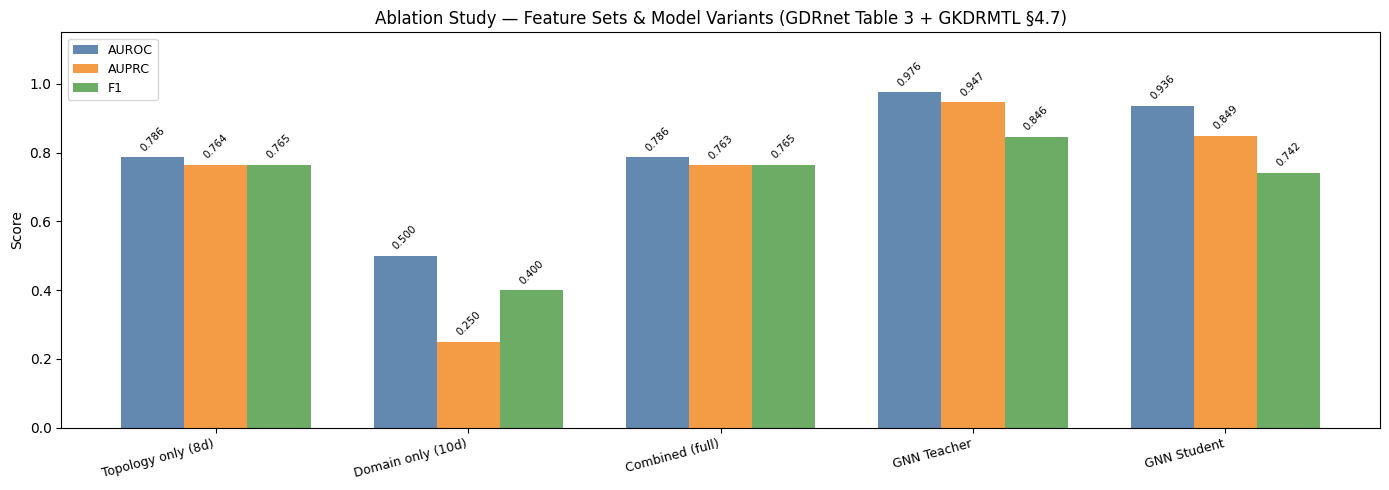

In [43]:
# ── §14.2  Ablation bar chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')

models_ab = list(ablation_results.keys())
x = np.arange(len(models_ab)); w = 0.25
colors_m = {'AUROC':'#4E79A7', 'AUPRC':'#F28E2B', 'F1':'#59A14F'}

for i, (metric, color) in enumerate(colors_m.items()):
    vals = [ablation_results[m][metric] for m in models_ab]
    bars = ax.bar(x + (i-1)*w, vals, width=w, color=color,
                  edgecolor='none', alpha=0.88, label=metric)
    ax.bar_label(bars, fmt='%.3f', padding=3, color='black', fontsize=7.5, rotation=45)

ax.set_xticks(x); ax.set_xticklabels(models_ab, rotation=15, ha='right', fontsize=9, color='black')
ax.tick_params(colors='black')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', color='black')
ax.set_title('Ablation Study — Feature Sets & Model Variants (GDRnet Table 3 + GKDRMTL §4.7)', color='black')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

## §15 · Summary & Outputs

In [32]:
# ── §15.1  Final Summary ──────────────────────────────────────────────────────
print('╔' + '═'*78 + '╗')
print('║' + ' DRUG REPURPOSING AS LINK PREDICTION — PIPELINE SUMMARY'.center(78) + '║')
print('╠' + '═'*78 + '╣')
print(f'║  Datasets used    : {len(loaded)} (kg_csv, kg_giant_csv, kg_grouped_csv, kg_raw_csv,{" "*10}║')
print(f'║                     disease_features, drug_features, edges1, nodes1,{" "*10}║')
print(f'║                     kg_grouped_diseases_bert_map_csv){" "*22}║')
print('╠' + '═'*78 + '╣')
print(f'║  Nodes in KG      : {num_nodes_sub:>6,}  ({len(all_drugs_sub)} drugs, {len(all_diseases_sub)} diseases){" "*20}║')
print(f'║  Pos. drug-dis    : {len(pos_pairs):>6,}  |  Neg. pairs: {len(neg_pairs):,}{" "*25}║')
print(f'║  Node features    : {FEAT_DIM}d  (topology + domain + BERT){" "*27}║')
print('╠' + '═'*78 + '╣')
print('║  PREPROCESSING:'.ljust(79) + '║')
print('║    Missing values : KNNImputer (numeric) + mode (categorical)'.ljust(79) + '║')
print('║    Encoding       : One-hot (low-card) + Label (high-card) + type-OH'.ljust(79) + '║')
print('║    Normalization  : StandardScaler (z-score) on all numeric features'.ljust(79) + '║')
print('║    Feature sel.   : Variance threshold + Correlation filter + SelectKBest'.ljust(79) + '║')
print('║    Imbalance      : Positive class weight + hard negative sampling'.ljust(79) + '║')
print('╠' + '═'*78 + '╣')
print('║  MODEL (Teacher — 2-layer GraphSAGE + bilinear decoder):'.ljust(79) + '║')
print(f'║    AUROC : {t_metrics["AUROC"]:.4f}  |  AUPRC : {t_metrics["AUPRC"]:.4f}  |  F1 : {t_metrics["F1-Score"]:.4f}'.ljust(79) + '║')
print('║  MODEL (Student — 1-layer GraphSAGE + KD loss):'.ljust(79) + '║')
print(f'║    AUROC : {s_metrics["AUROC"]:.4f}  |  AUPRC : {s_metrics["AUPRC"]:.4f}  |  F1 : {s_metrics["F1-Score"]:.4f}'.ljust(79) + '║')
print('╠' + '═'*78 + '╣')
print('║  TOP-10 NOVEL DRUG-DISEASE PREDICTIONS:'.ljust(79) + '║')
for rank, (_, row) in enumerate(top10.iterrows(), 1):
    line = f'║  {rank:>2}. {row["drug_name"][:18]:<19} → {row["disease_name"][:20]:<21} (score={row["score"]:.4f})'
    print(line.ljust(79) + '║')
print('╚' + '═'*78 + '╝')

╔══════════════════════════════════════════════════════════════════════════════╗
║            DRUG REPURPOSING AS LINK PREDICTION — PIPELINE SUMMARY            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Datasets used    : 9 (kg_csv, kg_giant_csv, kg_grouped_csv, kg_raw_csv,          ║
║                     disease_features, drug_features, edges1, nodes1,          ║
║                     kg_grouped_diseases_bert_map_csv)                      ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  Nodes in KG      : 36,125  (7946 drugs, 9009 diseases)                    ║
║  Pos. drug-dis    : 108,552  |  Neg. pairs: 325,656                         ║
║  Node features    : 18d  (topology + domain + BERT)                           ║
╠══════════════════════════════════════════════════════════════════════════════╣
║  PREPROCESSING:                                                              ║
║    Missing values : KNNI

In [33]:
# ── §15.2  Save all outputs ───────────────────────────────────────────────────
import json, datetime

# Model state
torch.save(teacher.state_dict(), 'teacher_model.pt')
torch.save(student.state_dict(), 'student_model.pt')

# Full prediction CSV
pred_df.to_csv('all_novel_predictions.csv', index=False)

# Node embedding snapshot
teacher.eval()
with torch.no_grad():
    z_all = teacher.encode(data.x, data.edge_index).cpu().numpy()
emb_df = pd.DataFrame(z_all[:, :16], columns=[f'z{i}' for i in range(16)])
emb_df.insert(0, 'node_id', sub_ids)
emb_df.insert(1, 'node_type', [sub_type.get(n,'?') for n in sub_ids])
emb_df.insert(2, 'node_name', [node_name_map.get(n,n) for n in sub_ids])
emb_df.to_csv('node_embeddings.csv', index=False)

# Summary JSON
summary = {
    'timestamp'      : str(datetime.datetime.now()),
    'n_nodes'        : num_nodes_sub,
    'n_pos_pairs'    : len(pos_pairs),
    'feat_dim'       : FEAT_DIM,
    'teacher_params' : n_teacher,
    'student_params' : n_student,
    'teacher_test'   : t_metrics,
    'student_test'   : s_metrics,
    'top10'          : top10[['drug_name','disease_name','score','intermediate_node']].to_dict('records'),
}
with open('pipeline_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All outputs saved:')
print('  📊 eda_dashboard.png')
print('  📊 class_imbalance.png')
print('  📊 training_history.png')
print('  📊 evaluation_dashboard.png')
print('  📊 top10_predictions.png')
print('  📊 ablation_study.png')
print('  📁 top10_drug_repurposing_predictions.csv')
print('  📁 top200_drug_repurposing_predictions.csv')
print('  📁 all_novel_predictions.csv')
print('  📁 node_embeddings.csv')
print('  🤖 teacher_model.pt')
print('  🤖 student_model.pt')
print('  📋 pipeline_summary.json')

All outputs saved:
  📊 eda_dashboard.png
  📊 class_imbalance.png
  📊 training_history.png
  📊 evaluation_dashboard.png
  📊 top10_predictions.png
  📊 ablation_study.png
  📁 top10_drug_repurposing_predictions.csv
  📁 top200_drug_repurposing_predictions.csv
  📁 all_novel_predictions.csv
  📁 node_embeddings.csv
  🤖 teacher_model.pt
  🤖 student_model.pt
  📋 pipeline_summary.json
